In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from scipy.stats import spearmanr, rankdata
from joblib import Parallel, delayed
import warnings
import gc
import argparse
from tqdm.auto import tqdm
import glob
import matplotlib.pyplot as plt
import networkx as nx
import re
import sys

In [3]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score

In [8]:
#Path to TwINFER code repository
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/"
os.makedirs(path_to_plot_data, exist_ok = True)

In [86]:
# ============================================================
# Fonts / plotting defaults
# ============================================================
import matplotlib.font_manager as fm

font_paths = [
    f"{path_to_code_repo}/fonts//Arial.ttf",
    f"{path_to_code_repo}/fonts//Arial Bold.ttf",
    f"{path_to_code_repo}/fonts//Arial Italic.ttf",
    f"{path_to_code_repo}/fonts//Arial Bold Italic.ttf",
]
for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.dpi'] = 400
plt.rcParams['axes.grid'] = False

✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts//Arial.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts//Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts//Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER//fonts//Arial Bold Italic.ttf


In [10]:
# Calculation functions
import sys
sys.path.append(str(path_to_code_repo))
import importlib
from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers
from TwINFER_function_scripts import infer_with_twinfer

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)
importlib.reload(infer_with_twinfer)

from TwINFER_function_scripts.correlation_analysis_functions import (
    generate_random_shuffle
)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    split_and_merge_simulations,
    get_param_data, 
    plot_matrix_as_heatmap,
)

from TwINFER_function_scripts.infer_with_twinfer import (
    infer_with_twinfer
)

## three gene motifs

### fan-out

In [13]:
import os
import pandas as pd
from pathlib import Path
# Base configuration template
base_config_five_gene = {
    'n_cells': 6000,
    'simulation_time_before_division': 2000,
    'twin_simulation_time_after_division': 48,
    'twin_measurement_resolution': 1,
    "path_to_connectivity_matrix": f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_fan_out.txt",  # Will be updated per network type
    "param_csv":f"{path_to_code_repo}/simulation_example_input_data/median_parameter.csv",  # Will be updated per network type
    "rows_to_use": [[0,0,0]],
    "log_file": None,  # Will be updated per network type
    "type": "fan-out",  # Will be updated per network type
    "number_of_parallel_parameters": 1,
    "number_of_cores_per_parameter": 18
}

In [ ]:
def process_matrix(twinfer_kwargs, id):
    # Process each network type
    all_correlation_matrices = {}
    
    # Use the first CSV file found (or you can add logic to select specific one)        
    # Update config for this network type
    config = twinfer_kwargs['base_config']
    network_type = "fan-out" 

    def make_json_safe(obj):
        if hasattr(obj, "to_dict"):      # pandas DataFrame / Series
            return obj.to_dict()
        if isinstance(obj, set):
            return list(obj)
        return obj
        
    # Check if required files exist
    if not os.path.exists(config["path_to_connectivity_matrix"]):
        print(f"Warning: Connectivity matrix not found for {network_type}")

    if not os.path.exists(config["param_csv"]):
        print(f"Warning: Parameter CSV not found for {network_type}")
    correlation_matrices = []
    try:
        print("running")
        # Run inference for this network type
        correlation_matrices = infer_with_twinfer(
            **twinfer_kwargs
            )
            

    except Exception as e:
        raise(f"Error processing {network_type}: {str(e)}")
    
    import json
    # Store the correlation matrices
    all_correlation_matrices[network_type] = correlation_matrices
        
    # Save the directional correlation matrix for this network type
    json_safe = {
        k: make_json_safe(v)
        for k, v in correlation_matrices.items()
    }
    path_to_json_file = f"{path_to_plot_data}fan_out_{id}.json"
    with open(path_to_json_file, "w") as f:
        json.dump(json_safe, f, indent=2)
    print(correlation_matrices.keys())
    correlation_file_name = f"{path_to_plot_data}/filtered_directional_correlation_type_{network_type}_{id}.csv"
    gene_correlation_file_name = f"{path_to_plot_data}/gene_correlation_type_{network_type}_{id}.csv"
    correlation_matrices['unfiltered_direction_matrix'].to_csv(correlation_file_name)
    correlation_matrices['pairwise_gene_gene_correlation_matrix'].to_csv(gene_correlation_file_name)
    correlation_matrices
    print(f"Successfully processed {network_type}")
    print(f"Saved correlation matrix to: {correlation_file_name}")
    return

path_to_simulations = f"//home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/"
prefix = "df_rows_0_0_0_"

list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix) and "Fan_out_additive" in f.name
]
len(list_simulations)

In [ ]:
%%capture

for id, file_name in enumerate(list_simulations):
    twinfer_kwargs = {
    "path_to_simulation_file": file_name,
    "base_config": base_config_five_gene,
    "t1": 1,  #time [hours] after division when t1 sample is collected
    "t2": 20, #time [hours] after division when t2 sample is collected
    "check_for_steady_state": True,
    "threshold_gene_gene_corr": 0.04, #Use direct threshold (used ONLY if use_scramble is False)
    "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
    "p_val_threshold_scrambled_gene_correlation": 0.02, #used ONLY if use_scramble is True
    "show_scrambled_distribution_gene_correlation": True, 
    "z_score_threshold_two_states": 12, #Z-score threshold to detect multi-states in the system
    "p_value_threshold_cross_correlation": 0.02,
    "plot_correlation_matrices_as_heatmap": True,
    "have_any_output": True,
    "seed": 101010,
    "infer_direction_for_which_edges": 'all-potential-regulation', #can be either single-state, all-potential-regulation (gene correlation is significant) or all-edges,
    "merge_time_points": True, #If True, then cells from the two timepoints will be used to calculate gene correlations and random-pair difference correlations
    "n_cores": 18,
    "match_sim_details": False
    }
    process_matrix(twinfer_kwargs, id)

In [ ]:
import json
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
matrix_file = Path(f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_fan_out.txt")
json_dir    = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/")          # contains edges_1.json, edges_2.json, ...
# plot_dir    = Path("path/to/output/plots")
# plot_dir.mkdir(parents=True, exist_ok=True)

json_files = sorted(json_dir.glob("fan_out*.json"))


# ============================================================
# LOAD BINARY MATRIX (ONCE)
# ============================================================
gt = pd.read_csv(matrix_file, header=None)
n = gt.shape[0]
genes = [f"gene_{i+1}" for i in range(n)]
gt.index = genes
gt.columns = genes

gene_labels = [f"g{i+1}" for i in range(n)]

from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Rectangle
import seaborn as sns
from pathlib import Path

def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = (0 - vmin) / (vmax - vmin)
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)


metrics_df_fan_out = []

# ============================================================
# MAIN LOOP
# ============================================================
for jf in json_files:

    # ---------------- load JSON ----------------
    with open(jf, "r") as f:
        cm = json.load(f)

    final_directed_edges = cm["final_directed_edges"]
    unfiltered_direction_matrix = pd.DataFrame(cm["unfiltered_direction_matrix"])
    multiple_states_and_reg = cm["gene_lists"]["multiple_states_and_reg"]
    all_gene_pairs = cm['all_gene_pairs']

    # enforce gene order
    unfiltered_direction_matrix.index = genes
    unfiltered_direction_matrix.columns = genes

    # ---------------- score ----------------
    # ============================================================
    # DIRECTED EDGE SCORING WITH ONE EXCEPTION (g2,g3)
    # ============================================================
    FP_edge = []
    FN_edge = []
    TP = FP = FN = TN = 0

    # quick lookup for predicted edges
    predicted_edges = set(tuple(e) for e in final_directed_edges)

    # special unordered exception pair
    EXCEPTION_PAIR = frozenset(["gene_2", "gene_3"])
    can_be_2_states =  [["gene_2", "gene_3"]]

    for i, gi in enumerate(genes):
        for j, gj in enumerate(genes):
            if gi == gj:
                continue

            pair = frozenset([gi, gj])

            # ----------------------------------------------------
            # EXCEPTION: (gene_2, gene_3)
            # ----------------------------------------------------
            if pair == EXCEPTION_PAIR:
                # evaluate ONCE per unordered pair
                if gi > gj:
                    continue  # avoid double counting

                has_gi_gj = (gi, gj) in predicted_edges
                has_gj_gi = (gj, gi) in predicted_edges

                if (has_gi_gj and has_gj_gi) or (not has_gi_gj and not has_gj_gi):
                    if [gi, gj] in multiple_states_and_reg or [gj, gi] in multiple_states_and_reg:
                        print(gi, gj, multiple_states_and_reg)
                        continue
                    else:
                        FP += 2
                        FP_edge.append((gi,gj))
                        FP_edge.append((gj, gi))
                else:
                    FP += 1
                    FP_edge.append((gi,gj))
                continue

            # ----------------------------------------------------
            # NORMAL DIRECTED SCORING
            # ----------------------------------------------------
            gt_edge = gt.loc[gi, gj] == 1
            pred_edge = (gi, gj) in predicted_edges

            if gt_edge and pred_edge:
                if [gi, gj] in multiple_states_and_reg and [gi, gj] not in can_be_2_states:
                    FN += 1
                    FN_edge.append((gi,gj))
                else:
                    TP += 1
            elif gt_edge and not pred_edge:
                FN += 1
                FN_edge.append((gi,gj))
            elif not gt_edge and pred_edge:
                FP += 1
                FP_edge.append((gi,gj))
            else:
                TN += 1

    # ============================================================
    # METRICS
    # ============================================================
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"F1={f1:.4f}")
    print(f"FP: {FP_edge}")
    print(f"FN: {FN_edge}")

    metrics_df_fan_out.append({
        "json": jf.name,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    #Plot TwINFER output
    gene_list = sorted(
        {g for pair in all_gene_pairs for g in pair},
        key=lambda x: int(x.split("_")[1])
    )
    gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
    # direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
    data_matrix = unfiltered_direction_matrix.to_numpy(float)
    masked_matrix = np.fill_diagonal(data_matrix, np.nan)
    fig = plt.figure(figsize=(6,6))
    gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
    cbar_ax = fig.add_subplot(gs[0])
    heatmap_ax = fig.add_subplot(gs[1])
    plot_matrix = data_matrix.copy()
    plot_matrix[:] = 0.0

    # Restore only final-ege correlations
    for g1, g2 in final_directed_edges:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            plot_matrix[i, j] = data_matrix[i, j]
            plot_matrix[j, i] = data_matrix[j, i]
    np.fill_diagonal(plot_matrix, np.nan)
    # vmin = np.nanmin(plot_matrix)
    # vmax = np.nanmax(plot_matrix)
    vmin = 0.0
    vmax = 0.15
    cmap = make_reds_blues_colormap(vmin = vmin, vmax = vmax)

    cmap.set_bad(color="#D9D9D9")
    # --- draw heatmap ---
    sns.heatmap(
        plot_matrix,
        ax=heatmap_ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        square=True,
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={'orientation': 'horizontal'},
        linewidths=0.5,
        linecolor="black",
        # center=center
    )
    for g1, g2 in multiple_states_and_reg:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            print(i, j)

            # Draw diagonal in cell (i, j) - top-left to bottom-right
            heatmap_ax.plot(
                [j, j+1],      # x: left → right
                [i, i+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )
            
            # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
            heatmap_ax.plot(
                [i, i+1],      # x: left → right
                [j, j+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )

    # --- labels ---
    cbar_ax.xaxis.set_label_position('top')
    cbar_ax.xaxis.tick_top()

    n = len(gene_labels)
    tick_pos = np.arange(n) + 0.5

    heatmap_ax.set_xticks(tick_pos)
    heatmap_ax.set_yticks(tick_pos)
    heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
    heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")

    # keep limits tight to cells
    heatmap_ax.set_xlim(0, n)
    heatmap_ax.set_ylim(n, 0)

    # --- transparent background ---
    # plt.tight_layout()
    fig.patch.set_alpha(0)
    for ax in [heatmap_ax, cbar_ax]:
        ax.set_facecolor("none")
    for im in heatmap_ax.get_images() + cbar_ax.get_images():
        im.set_facecolor((1, 1, 1, 0))
        im.set_edgecolor((1, 1, 1, 0))
    for spine in heatmap_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
        spine.set_clip_on(False)

    plt.show()

# ============================================================
# METRICS SUMMARY
# ============================================================
metrics_df_fan_out = pd.DataFrame(metrics_df_fan_out)
print(metrics_df_fan_out)

### feed-forward

In [ ]:
def process_matrix(twinfer_kwargs, id):
    # Process each network type
    all_correlation_matrices = {}
    
    # Use the first CSV file found (or you can add logic to select specific one)        
    # Update config for this network type
    config = twinfer_kwargs['base_config']
    network_type = "feed-forward" 

    def make_json_safe(obj):
        if hasattr(obj, "to_dict"):      # pandas DataFrame / Series
            return obj.to_dict()
        if isinstance(obj, set):
            return list(obj)
        return obj
        
    # Check if required files exist
    if not os.path.exists(config["path_to_connectivity_matrix"]):
        print(f"Warning: Connectivity matrix not found for {network_type}")

    if not os.path.exists(config["param_csv"]):
        print(f"Warning: Parameter CSV not found for {network_type}")
    correlation_matrices = []
    try:
        print("running")
        # Run inference for this network type
        correlation_matrices = infer_with_twinfer(
            **twinfer_kwargs
            )
            

    except Exception as e:
        raise(f"Error processing {network_type}: {str(e)}")
    
    import json
    # Store the correlation matrices
    all_correlation_matrices[network_type] = correlation_matrices
        
    # Save the directional correlation matrix for this network type
    json_safe = {
        k: make_json_safe(v)
        for k, v in correlation_matrices.items()
    }
    path_to_json_file = f"{path_to_plot_data}feed_forward{id}.json"
    with open(path_to_json_file, "w") as f:
        json.dump(json_safe, f, indent=2)
    print(correlation_matrices.keys())
    correlation_file_name = f"{path_to_plot_data}/filtered_directional_correlation_type_{network_type}_{id}.csv"
    gene_correlation_file_name = f"{path_to_plot_data}/gene_correlation_type_{network_type}_{id}.csv"
    correlation_matrices['unfiltered_direction_matrix'].to_csv(correlation_file_name)
    correlation_matrices['pairwise_gene_gene_correlation_matrix'].to_csv(gene_correlation_file_name)
    correlation_matrices
    print(f"Successfully processed {network_type}")
    print(f"Saved correlation matrix to: {correlation_file_name}")
    return

path_to_simulations = f"//home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/"
prefix = "df_rows_0_0_0_"

list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix) and "Feed_forward_additive" in f.name
]
len(list_simulations)

In [17]:
%%capture
for id, file_name in enumerate(list_simulations):
    twinfer_kwargs = {
    "path_to_simulation_file": file_name,
    "base_config": base_config_five_gene,
    "t1":1,
    "t2": 20, #time [hours] after division when t2 sample is collected
    "check_for_steady_state": True,
    "threshold_gene_gene_corr": 0.04, #Use direct threshold (used ONLY if use_scramble is False)
    "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
    "p_val_threshold_scrambled_gene_correlation": 0.02, #used ONLY if use_scramble is True
    "show_scrambled_distribution_gene_correlation": True, 
    "z_score_threshold_two_states": 12, #Z-score threshold to detect multi-states in the system
    "p_value_threshold_cross_correlation": 0.02,
    "plot_correlation_matrices_as_heatmap": True,
    "have_any_output": True,
    "seed": 101010,
    "infer_direction_for_which_edges": 'all-potential-regulation', #can be either single-state, all-potential-regulation (gene correlation is significant) or all-edges,
    "merge_time_points": True, #If True, then cells from the two timepoints will be used to calculate gene correlations and random-pair difference correlations
    "n_cores": 18,
    "match_sim_details": False
    }
    
    process_matrix(twinfer_kwargs, id)

In [ ]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
# ============================================================
# PATHS
# ============================================================
matrix_file = Path(f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_feed_forward.txt")
json_dir    = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/")          # contains edges_1.json, edges_2.json, ...
# plot_dir    = Path("path/to/output/plots")
# plot_dir.mkdir(parents=True, exist_ok=True)

json_files = sorted(json_dir.glob("feed_forward*.json"))

# ============================================================
# LOAD BINARY MATRIX (ONCE)
# ============================================================
gt = pd.read_csv(matrix_file, header=None)
n = gt.shape[0]
genes = [f"gene_{i+1}" for i in range(n)]
gt.index = genes
gt.columns = genes

gene_labels = [f"g{i+1}" for i in range(n)]

metrics_df_feed_forward = []

# ============================================================
# MAIN LOOP
# ============================================================
for jf in json_files:
    # ---------------- load JSON ----------------
    with open(jf, "r") as f:
        cm = json.load(f)

    final_directed_edges = cm["final_directed_edges"]
    unfiltered_direction_matrix = pd.DataFrame(cm["unfiltered_direction_matrix"])
    multiple_states_and_reg = cm["gene_lists"]["multiple_states_and_reg"]
    all_gene_pairs = cm['all_gene_pairs']

    # enforce gene order
    unfiltered_direction_matrix.index = genes
    unfiltered_direction_matrix.columns = genes

    # ---------------- score ----------------
    # ============================================================
    # DIRECTED EDGE SCORING WITH ONE EXCEPTION (g2,g3)
    # ============================================================
    FP_edge = []
    FN_edge = []
    TP = FP = FN = TN = 0

    # quick lookup for predicted edges
    predicted_edges = set(tuple(e) for e in final_directed_edges)

    # special unordered exception pair
    EXCEPTION_PAIR = frozenset()
    can_be_2_states =  [["gene_2", "gene_3"]]

    for i, gi in enumerate(genes):
        for j, gj in enumerate(genes):
            if gi == gj:
                continue

            pair = frozenset([gi, gj])

            # ----------------------------------------------------
            # EXCEPTION: (gene_2, gene_3)
            # ----------------------------------------------------
            if pair == EXCEPTION_PAIR:
                # evaluate ONCE per unordered pair
                if gi > gj:
                    continue  # avoid double counting

                has_gi_gj = (gi, gj) in predicted_edges
                has_gj_gi = (gj, gi) in predicted_edges

                if (has_gi_gj and has_gj_gi) or (not has_gi_gj and not has_gj_gi):
                    if [gi, gj] in multiple_states_and_reg or [gj, gi] in multiple_states_and_reg:
                        print(gi, gj, multiple_states_and_reg)
                        continue
                    else:
                        FP += 2
                        FP_edge.append((gi,gj))
                        FP_edge.append((gj, gi))
                else:
                    FP += 1
                    FP_edge.append((gi,gj))
                continue

            # ----------------------------------------------------
            # NORMAL DIRECTED SCORING
            # ----------------------------------------------------
            gt_edge = gt.loc[gi, gj] == 1
            pred_edge = (gi, gj) in predicted_edges

            if gt_edge and pred_edge:
                if [gi, gj] in multiple_states_and_reg and [gi, gj] not in can_be_2_states:
                    FN += 1
                    FN_edge.append((gi,gj))
                else:
                    TP += 1
            elif gt_edge and not pred_edge:
                FN += 1
                FN_edge.append((gi,gj))
            elif not gt_edge and pred_edge:
                FP += 1
                FP_edge.append((gi,gj))
            else:
                TN += 1

    # ============================================================
    # METRICS
    # ============================================================
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"F1={f1:.4f}")
    print(f"FP: {FP_edge}")
    print(f"FN: {FN_edge}")

    metrics_df_feed_forward.append({
        "json": jf.name,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    #Plot TwINFER output
    gene_list = sorted(
        {g for pair in all_gene_pairs for g in pair},
        key=lambda x: int(x.split("_")[1])
    )
    gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
    # direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
    data_matrix = unfiltered_direction_matrix.to_numpy(float)
    masked_matrix = np.fill_diagonal(data_matrix, np.nan)
    fig = plt.figure(figsize=(6,6))
    gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
    cbar_ax = fig.add_subplot(gs[0])
    heatmap_ax = fig.add_subplot(gs[1])
    plot_matrix = data_matrix.copy()
    plot_matrix[:] = 0.0

    # Restore only final-ege correlations
    for g1, g2 in final_directed_edges:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            plot_matrix[i, j] = data_matrix[i, j]
            plot_matrix[j, i] = data_matrix[j, i]
    np.fill_diagonal(plot_matrix, np.nan)
    # vmin = np.nanmin(plot_matrix)
    # vmax = np.nanmax(plot_matrix)
    vmin = 0.0
    vmax = 0.15
    cmap = make_reds_blues_colormap(vmin = vmin, vmax = vmax)

    cmap.set_bad(color="#D9D9D9")
    # --- draw heatmap ---
    sns.heatmap(
        plot_matrix,
        ax=heatmap_ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        square=True,
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={'orientation': 'horizontal'},
        linewidths=0.5,
        linecolor="black",
        # center=center
    )
    for g1, g2 in multiple_states_and_reg:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            print(i, j)

            # Draw diagonal in cell (i, j) - top-left to bottom-right
            heatmap_ax.plot(
                [j, j+1],      # x: left → right
                [i, i+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )
            
            # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
            heatmap_ax.plot(
                [i, i+1],      # x: left → right
                [j, j+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )

    # --- labels ---
    cbar_ax.xaxis.set_label_position('top')
    cbar_ax.xaxis.tick_top()

    n = len(gene_labels)
    tick_pos = np.arange(n) + 0.5

    heatmap_ax.set_xticks(tick_pos)
    heatmap_ax.set_yticks(tick_pos)
    heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
    heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")

    # keep limits tight to cells
    heatmap_ax.set_xlim(0, n)
    heatmap_ax.set_ylim(n, 0)

    # --- transparent background ---
    # plt.tight_layout()
    fig.patch.set_alpha(0)
    for ax in [heatmap_ax, cbar_ax]:
        ax.set_facecolor("none")
    for im in heatmap_ax.get_images() + cbar_ax.get_images():
        im.set_facecolor((1, 1, 1, 0))
        im.set_edgecolor((1, 1, 1, 0))
    for spine in heatmap_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
        spine.set_clip_on(False)

    plt.close()

# ============================================================
# METRICS SUMMARY
# ============================================================
metrics_df_feed_forward = pd.DataFrame(metrics_df_feed_forward)
print(metrics_df_feed_forward)

### mutual regulation

In [ ]:
def process_matrix(twinfer_kwargs, id):
    # Process each network type
    all_correlation_matrices = {}
    
    # Use the first CSV file found (or you can add logic to select specific one)        
    # Update config for this network type
    config = twinfer_kwargs['base_config']
    network_type = "mutual-regulation" 

    def make_json_safe(obj):
        if hasattr(obj, "to_dict"):      # pandas DataFrame / Series
            return obj.to_dict()
        if isinstance(obj, set):
            return list(obj)
        return obj
        
    # Check if required files exist
    if not os.path.exists(config["path_to_connectivity_matrix"]):
        print(f"Warning: Connectivity matrix not found for {network_type}")

    if not os.path.exists(config["param_csv"]):
        print(f"Warning: Parameter CSV not found for {network_type}")
    correlation_matrices = []
    try:
        print("running")
        # Run inference for this network type
        correlation_matrices = infer_with_twinfer(
            **twinfer_kwargs
            )
            

    except Exception as e:
        raise(f"Error processing {network_type}: {str(e)}")
    
    import json
    # Store the correlation matrices
    all_correlation_matrices[network_type] = correlation_matrices
        
    # Save the directional correlation matrix for this network type
    json_safe = {
        k: make_json_safe(v)
        for k, v in correlation_matrices.items()
    }
    path_to_json_file = f"{path_to_plot_data}/mutual_regulation{id}.json"
    print(path_to_json_file)
    with open(path_to_json_file, "w") as f:
        json.dump(json_safe, f, indent=2)
    print(correlation_matrices.keys())
    correlation_file_name = f"{path_to_plot_data}/filtered_directional_correlation_type_{network_type}_{id}.csv"
    gene_correlation_file_name = f"{path_to_plot_data}/gene_correlation_type_{network_type}_{id}.csv"
    correlation_matrices['unfiltered_direction_matrix'].to_csv(correlation_file_name)
    correlation_matrices['pairwise_gene_gene_correlation_matrix'].to_csv(gene_correlation_file_name)
    correlation_matrices
    print(f"Successfully processed {network_type}")
    print(f"Saved correlation matrix to: {correlation_file_name}")
    return

path_to_simulations = f"//home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim_all_variants/"
prefix = "df_rows_0_0_0_"

list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix) and "Mutual_regulation_additive" in f.name
]
list_simulations

In [ ]:
%%capture

for id, file_name in enumerate(list_simulations):
    if id < 10:
        continue
    twinfer_kwargs = {
    "path_to_simulation_file": file_name,
    "base_config": base_config_five_gene,
    "t1": 1,  #time [hours] after division when t1 sample is collected
    "t2": 20, #time [hours] after division when t2 sample is collected
    "check_for_steady_state": True,
    "threshold_gene_gene_corr": 0.04, #Use direct threshold (used ONLY if use_scramble is False)
    "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
    "p_val_threshold_scrambled_gene_correlation": 0.02, #used ONLY if use_scramble is True
    "show_scrambled_distribution_gene_correlation": True, 
    "z_score_threshold_two_states": 12, #Z-score threshold to detect multi-states in the system
    "p_value_threshold_cross_correlation": 0.02,
    "plot_correlation_matrices_as_heatmap": True,
    "have_any_output": True,
    "seed": 101010,
    "infer_direction_for_which_edges": 'all-potential-regulation', #can be either single-state, all-potential-regulation (gene correlation is significant) or all-edges,
    "merge_time_points": True, #If True, then cells from the two timepoints will be used to calculate gene correlations and random-pair difference correlations
    "n_cores": 10,
    "match_sim_details": False
    }
    process_matrix(twinfer_kwargs, id)

In [ ]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
matrix_file = Path(f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_mutual_regulation.txt")
json_dir    = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/")          # contains edges_1.json, edges_2.json, ...
# plot_dir    = Path("path/to/output/plots")
# plot_dir.mkdir(parents=True, exist_ok=True)

json_files = sorted(json_dir.glob("mutual_regulation*.json"))


# ============================================================
# LOAD BINARY MATRIX (ONCE)
# ============================================================
gt = pd.read_csv(matrix_file, header=None)
n = gt.shape[0]
genes = [f"gene_{i+1}" for i in range(n)]
gt.index = genes
gt.columns = genes

gene_labels = [f"g{i+1}" for i in range(n)]

metrics_df_mutual_regulation = []

# ============================================================
# MAIN LOOP
# ============================================================
for jf in json_files:

    # ---------------- load JSON ----------------
    with open(jf, "r") as f:
        cm = json.load(f)

    final_directed_edges = cm["final_directed_edges"]
    unfiltered_direction_matrix = pd.DataFrame(cm["unfiltered_direction_matrix"])
    multiple_states_and_reg = cm["gene_lists"]["multiple_states_and_reg"]
    all_gene_pairs = cm['all_gene_pairs']

    # enforce gene order
    unfiltered_direction_matrix.index = genes
    unfiltered_direction_matrix.columns = genes

    # ---------------- score ----------------
    # ============================================================
    # DIRECTED EDGE SCORING WITH ONE EXCEPTION (g2,g3)
    # ============================================================
    FP_edge = []
    FN_edge = []
    TP = FP = FN = TN = 0

    # quick lookup for predicted edges
    predicted_edges = set(tuple(e) for e in final_directed_edges)

    # special unordered exception pair
    EXCEPTION_PAIR = frozenset()
    can_be_2_states =  []

    for i, gi in enumerate(genes):
        for j, gj in enumerate(genes):
            if gi == gj:
                continue

            pair = frozenset([gi, gj])

            # ----------------------------------------------------
            # EXCEPTION: (gene_2, gene_3)
            # ----------------------------------------------------
            if pair == EXCEPTION_PAIR:
                # evaluate ONCE per unordered pair
                if gi > gj:
                    continue  # avoid double counting

                has_gi_gj = (gi, gj) in predicted_edges
                has_gj_gi = (gj, gi) in predicted_edges

                if (has_gi_gj and has_gj_gi) or (not has_gi_gj and not has_gj_gi):
                    if [gi, gj] in multiple_states_and_reg or [gj, gi] in multiple_states_and_reg:
                        print(gi, gj, multiple_states_and_reg)
                        continue
                    else:
                        FP += 2
                        FP_edge.append((gi,gj))
                        FP_edge.append((gj, gi))
                else:
                    FP += 1
                    FP_edge.append((gi,gj))
                continue

            # ----------------------------------------------------
            # NORMAL DIRECTED SCORING
            # ----------------------------------------------------
            gt_edge = gt.loc[gi, gj] == 1
            pred_edge = (gi, gj) in predicted_edges

            if gt_edge and pred_edge:
                if [gi, gj] in multiple_states_and_reg and [gi, gj] not in can_be_2_states:
                    FN += 1
                    FN_edge.append((gi,gj))
                else:
                    TP += 1
            elif gt_edge and not pred_edge:
                FN += 1
                FN_edge.append((gi,gj))
            elif not gt_edge and pred_edge:
                FP += 1
                FP_edge.append((gi,gj))
            else:
                TN += 1

    # ============================================================
    # METRICS
    # ============================================================
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"F1={f1:.4f}")
    print(f"FP: {FP_edge}")
    print(f"FN: {FN_edge}")

    metrics_df_mutual_regulation.append({
        "json": jf.name,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    #Plot TwINFER output
    gene_list = sorted(
        {g for pair in all_gene_pairs for g in pair},
        key=lambda x: int(x.split("_")[1])
    )
    gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
    # direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
    data_matrix = unfiltered_direction_matrix.to_numpy(float)
    masked_matrix = np.fill_diagonal(data_matrix, np.nan)
    fig = plt.figure(figsize=(6,6))
    gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
    cbar_ax = fig.add_subplot(gs[0])
    heatmap_ax = fig.add_subplot(gs[1])
    plot_matrix = data_matrix.copy()
    plot_matrix[:] = 0.0

    # Restore only final-ege correlations
    for g1, g2 in final_directed_edges:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            plot_matrix[i, j] = data_matrix[i, j]
            plot_matrix[j, i] = data_matrix[j, i]
    np.fill_diagonal(plot_matrix, np.nan)

    # vmin = np.nanmin(plot_matrix)
    # vmax = np.nanmax(plot_matrix)
    vmin = 0.0
    vmax = 0.15

    if np.isnan(vmin) or np.isnan(vmax) or vmin == vmax:
        # Force symmetric tiny range around zero
        vmin = vmin -1e-9
        vmax = vmax + 1e-9

    print(vmin, vmax)
    cmap = make_reds_blues_colormap(vmin = vmin, vmax = vmax)

    cmap.set_bad(color="#D9D9D9")
    # --- draw heatmap ---
    sns.heatmap(
        plot_matrix,
        ax=heatmap_ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        square=True,
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={'orientation': 'horizontal'},
        linewidths=0.5,
        linecolor="black",
        # center=center
    )
    for g1, g2 in multiple_states_and_reg:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            print(i, j)

            # Draw diagonal in cell (i, j) - top-left to bottom-right
            heatmap_ax.plot(
                [j, j+1],      # x: left → right
                [i, i+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )
            
            # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
            heatmap_ax.plot(
                [i, i+1],      # x: left → right
                [j, j+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )

    # --- labels ---
    cbar_ax.xaxis.set_label_position('top')
    cbar_ax.xaxis.tick_top()

    n = len(gene_labels)
    tick_pos = np.arange(n) + 0.5

    heatmap_ax.set_xticks(tick_pos)
    heatmap_ax.set_yticks(tick_pos)
    heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
    heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")

    # keep limits tight to cells
    heatmap_ax.set_xlim(0, n)
    heatmap_ax.set_ylim(n, 0)

    # --- transparent background ---
    # plt.tight_layout()
    fig.patch.set_alpha(0)
    for ax in [heatmap_ax, cbar_ax]:
        ax.set_facecolor("none")
    for im in heatmap_ax.get_images() + cbar_ax.get_images():
        im.set_facecolor((1, 1, 1, 0))
        im.set_edgecolor((1, 1, 1, 0))
    for spine in heatmap_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
        spine.set_clip_on(False)

    plt.close()

# ============================================================
# METRICS SUMMARY
# ============================================================
metrics_df_mutual_regulation = pd.DataFrame(metrics_df_mutual_regulation)
print(metrics_df_mutual_regulation)

## five gene cascade

In [11]:
import os
import pandas as pd
from pathlib import Path
# Base configuration template
base_config_five_gene = {
    'n_cells': 6000,
    'simulation_time_before_division': 1000,
    'twin_simulation_time_after_division': 24,
    'twin_measurement_resolution': 1,
    "path_to_connectivity_matrix": f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_5_gene_linear_cascade.txt",  # Will be updated per network type
    "param_csv":f"{path_to_code_repo}/simulation_example_input_data/median_parameter.csv",  # Will be updated per network type
    "rows_to_use": [[0,0,0,0,0]],
    "log_file": None,  # Will be updated per network type
    "type": None,  # Will be updated per network type
    "number_of_parallel_parameters": 1,
    "number_of_cores_per_parameter": 18
}

In [37]:
def process_matrix(twinfer_kwargs, id):
    # Process each network type
    all_correlation_matrices = {}
    
    # Use the first CSV file found (or you can add logic to select specific one)        
    # Update config for this network type
    config = twinfer_kwargs['base_config']
    network_type = "five_gene_cascade" 

    def make_json_safe(obj):
        if hasattr(obj, "to_dict"):      # pandas DataFrame / Series
            return obj.to_dict()
        if isinstance(obj, set):
            return list(obj)
        return obj
        
    # Check if required files exist
    if not os.path.exists(config["path_to_connectivity_matrix"]):
        print(f"Warning: Connectivity matrix not found for {network_type}")

    if not os.path.exists(config["param_csv"]):
        print(f"Warning: Parameter CSV not found for {network_type}")
    correlation_matrices = []
    try:
        print("running")
        # Run inference for this network type
        correlation_matrices = infer_with_twinfer(
            **twinfer_kwargs
            )
            

    except Exception as e:
        raise(f"Error processing {network_type}: {str(e)}")
    
    import json
    # Store the correlation matrices
    all_correlation_matrices[network_type] = correlation_matrices
        
    # Save the directional correlation matrix for this network type
    json_safe = {
        k: make_json_safe(v)
        for k, v in correlation_matrices.items()
    }
    path_to_json_file = f"{path_to_plot_data}five_gene_correlation_matrices_{id}.json"
    with open(path_to_json_file, "w") as f:
        json.dump(json_safe, f, indent=2)
    print(correlation_matrices.keys())
    correlation_file_name = f"{path_to_plot_data}/five_gene_filtered_directional_correlation_type_{network_type}_{id}.csv"
    gene_correlation_file_name = f"{path_to_plot_data}/five_gene_gene_correlation_type_{network_type}_{id}.csv"
    correlation_matrices['unfiltered_direction_matrix'].to_csv(correlation_file_name)
    correlation_matrices['pairwise_gene_gene_correlation_matrix'].to_csv(gene_correlation_file_name)
    correlation_matrices
    print(f"Successfully processed {network_type}")
    print(f"Saved correlation matrix to: {correlation_file_name}")
    return

In [38]:
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/median_simulation/figure_3_simulations"
prefix = "df_rows_0_0_0_0_0"

list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix) and "rep" in f.name
]


In [106]:
%%capture

for id, file_name in enumerate(list_simulations):
    twinfer_kwargs = {
    "path_to_simulation_file": file_name,
    "base_config": base_config_five_gene,
    "t1": 1,  #time [hours] after division when t1 sample is collected
    "t2": 20, #time [hours] after division when t2 sample is collected
    "check_for_steady_state": True,
    "threshold_gene_gene_corr": 0.04, #Use direct threshold (used ONLY if use_scramble is False)
    "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
    "p_val_threshold_scrambled_gene_correlation": 0.02, #used ONLY if use_scramble is True
    "show_scrambled_distribution_gene_correlation": True, 
    "z_score_threshold_two_states": 12, #Z-score threshold to detect multi-states in the system
    "p_value_threshold_cross_correlation": 0.02,
    "plot_correlation_matrices_as_heatmap": True,
    "have_any_output": True,
    "seed": 101010,
    "infer_direction_for_which_edges": 'all-potential-regulation', #can be either single-state, all-potential-regulation (gene correlation is significant) or all-edges,
    "merge_time_points": True, #If True, then cells from the two timepoints will be used to calculate gene correlations and random-pair difference correlations
    "n_cores": 18,
    "match_sim_details": False
    }
    process_matrix(twinfer_kwargs, id)

In [ ]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
matrix_file = Path(f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_5_gene_linear_cascade.txt")
json_dir    = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/")          # contains edges_1.json, edges_2.json, ...
# plot_dir    = Path("path/to/output/plots")
# plot_dir.mkdir(parents=True, exist_ok=True)

json_files = sorted(json_dir.glob("five_gene_correlation*.json"))


# ============================================================
# LOAD BINARY MATRIX (ONCE)
# ============================================================
gt = pd.read_csv(matrix_file, header=None)
n = gt.shape[0]
genes = [f"gene_{i+1}" for i in range(n)]
gt.index = genes
gt.columns = genes

gene_labels = [f"g{i+1}" for i in range(n)]

from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Rectangle
import seaborn as sns
from pathlib import Path

def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = (0 - vmin) / (vmax - vmin)
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)


metrics_five_gene_twinfer = []

# ============================================================
# MAIN LOOP
# ============================================================
for jf in json_files:

    # ---------------- load JSON ----------------
    with open(jf, "r") as f:
        cm = json.load(f)

    final_directed_edges = cm["final_directed_edges"]
    unfiltered_direction_matrix = pd.DataFrame(cm["unfiltered_direction_matrix"])
    multiple_states_and_reg = cm["gene_lists"]["multiple_states_and_reg"]
    all_gene_pairs = cm['all_gene_pairs']

    # enforce gene order
    unfiltered_direction_matrix.index = genes
    unfiltered_direction_matrix.columns = genes

    # ---------------- score ----------------
    # ============================================================
    # DIRECTED EDGE SCORING WITH ONE EXCEPTION (g2,g3)
    # ============================================================
    FP_edge = []
    FN_edge = []
    TP = FP = FN = TN = 0

    # quick lookup for predicted edges
    predicted_edges = set(tuple(e) for e in final_directed_edges)

    # special unordered exception pair
    EXCEPTION_PAIR = frozenset()
    can_be_2_states =  []

    for i, gi in enumerate(genes):
        for j, gj in enumerate(genes):
            if gi == gj:
                continue

            pair = frozenset([gi, gj])

            # ----------------------------------------------------
            # EXCEPTION: (gene_2, gene_3)
            # ----------------------------------------------------
            if pair == EXCEPTION_PAIR:
                # evaluate ONCE per unordered pair
                if gi > gj:
                    continue  # avoid double counting

                has_gi_gj = (gi, gj) in predicted_edges
                has_gj_gi = (gj, gi) in predicted_edges

                if (has_gi_gj and has_gj_gi) or (not has_gi_gj and not has_gj_gi):
                    if [gi, gj] in multiple_states_and_reg or [gj, gi] in multiple_states_and_reg:
                        print(gi, gj, multiple_states_and_reg)
                        continue
                    else:
                        FP += 2
                        FP_edge.append((gi,gj))
                        FP_edge.append((gj, gi))
                else:
                    FP += 1
                    FP_edge.append((gi,gj))
                continue

            # ----------------------------------------------------
            # NORMAL DIRECTED SCORING
            # ----------------------------------------------------
            gt_edge = gt.loc[gi, gj] == 1
            pred_edge = (gi, gj) in predicted_edges

            if gt_edge and pred_edge:
                if [gi, gj] in multiple_states_and_reg and [gi, gj] not in can_be_2_states:
                    FN += 1
                    FN_edge.append((gi,gj))
                else:
                    TP += 1
            elif gt_edge and not pred_edge:
                FN += 1
                FN_edge.append((gi,gj))
            elif not gt_edge and pred_edge:
                FP += 1
                FP_edge.append((gi,gj))
            else:
                TN += 1

    # ============================================================
    # METRICS
    # ============================================================
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"F1={f1:.4f}")
    print(f"FP: {FP_edge}")
    print(f"FN: {FN_edge}")

    metrics_five_gene_twinfer.append({
        "json": jf.name,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    #Plot TwINFER output
    gene_list = sorted(
        {g for pair in all_gene_pairs for g in pair},
        key=lambda x: int(x.split("_")[1])
    )
    gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
    # direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
    data_matrix = unfiltered_direction_matrix.to_numpy(float)
    masked_matrix = np.fill_diagonal(data_matrix, np.nan)
    fig = plt.figure(figsize=(6,6))
    gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
    cbar_ax = fig.add_subplot(gs[0])
    heatmap_ax = fig.add_subplot(gs[1])
    plot_matrix = data_matrix.copy()
    plot_matrix[:] = 0.0

    # Restore only final-ege correlations
    for g1, g2 in final_directed_edges:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            plot_matrix[i, j] = data_matrix[i, j]
            plot_matrix[j, i] = data_matrix[j, i]
    np.fill_diagonal(plot_matrix, np.nan)
    vmin = np.nanmin(plot_matrix)
    vmax = np.nanmax(plot_matrix)
    cmap = make_reds_blues_colormap(vmin = vmin, vmax = vmax)

    cmap.set_bad(color="#D9D9D9")
    # --- draw heatmap ---
    sns.heatmap(
        plot_matrix,
        ax=heatmap_ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        square=True,
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={'orientation': 'horizontal'},
        linewidths=0.5,
        linecolor="black",
        # center=center
    )
    for g1, g2 in multiple_states_and_reg:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            print(i, j)

            # Draw diagonal in cell (i, j) - top-left to bottom-right
            heatmap_ax.plot(
                [j, j+1],      # x: left → right
                [i, i+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )
            
            # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
            heatmap_ax.plot(
                [i, i+1],      # x: left → right
                [j, j+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )

    # --- labels ---
    cbar_ax.xaxis.set_label_position('top')
    cbar_ax.xaxis.tick_top()

    n = len(gene_labels)
    tick_pos = np.arange(n) + 0.5

    heatmap_ax.set_xticks(tick_pos)
    heatmap_ax.set_yticks(tick_pos)
    heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
    heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")

    # keep limits tight to cells
    heatmap_ax.set_xlim(0, n)
    heatmap_ax.set_ylim(n, 0)

    # --- transparent background ---
    # plt.tight_layout()
    fig.patch.set_alpha(0)
    for ax in [heatmap_ax, cbar_ax]:
        ax.set_facecolor("none")
    for im in heatmap_ax.get_images() + cbar_ax.get_images():
        im.set_facecolor((1, 1, 1, 0))
        im.set_edgecolor((1, 1, 1, 0))
    for spine in heatmap_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
        spine.set_clip_on(False)

    plt.close()

# ============================================================
# METRICS SUMMARY
# ============================================================
metrics_df_five_gene_Twinfer = pd.DataFrame(metrics_five_gene_twinfer)
print(metrics_df_five_gene_Twinfer)

#### grnBoost

In [30]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score

# ============================================================
# 1. Load ground-truth connectivity matrix
# ============================================================

gt_path = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/simulation_example_input_data/connectivity_matrix_5_gene_linear_cascade.txt"

# Load as numpy array
gt_matrix = np.loadtxt(gt_path, delimiter= ",")

n_genes = gt_matrix.shape[0]
genes = [f"gene_{i+1}_mRNA" for i in range(n_genes)]

gt_df = pd.DataFrame(
    gt_matrix,
    index=genes,
    columns=genes,
)

###SEARCH
# Binary ground truth: edge exists or not
gt_binary = (gt_df.values != 0).astype(int)
np.fill_diagonal(gt_binary, 0)

# ============================================================
# 2. Build predicted score matrix from network
# ============================================================
import os, pathlib
from pathlib import Path
network_files = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/")          # contains edges_1.json, edges_2.json, ...
list_network_files = sorted(network_files.glob("grn_boost_five_gene_cascade_inference_*.csv"))
best_rows = []
for i, network_path in enumerate(list_network_files):
    # ---------------- load network ----------------
    network = pd.read_csv(network_path)

    # ---------------- dense prediction matrix ----------------
    pred_df = (
        network
        .pivot(index="TF", columns="target", values="importance")
        .reindex(index=genes, columns=genes, fill_value=0.0)
    )
    np.fill_diagonal(pred_df.values, 0.0)

    # ---------------- vectorize for metrics ----------------
    y_true = gt_binary.flatten()
    y_score = pred_df.values.flatten()

    mask = ~np.eye(len(genes), dtype=bool).flatten()
    y_true = y_true[mask]
    y_score = y_score[mask]

    # ========================================================
    # Best-F1 threshold (dense, comparable to GT)
    # ========================================================
    rows = []
    for t in np.unique(y_score)[::-1]:
        y_pred = (y_score >= t).astype(int)
        if y_pred.sum() == 0:
            continue

        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "n_edges": y_pred.sum(),
        })

    best = pd.DataFrame(rows).loc[lambda df: df["f1"].idxmax()]

    # ========================================================
    # GMM threshold (fit on predicted edges ONLY)
    # ========================================================
    x = network["importance"].values.reshape(-1, 1)
    MIN_POINTS = 2
    if len(x) >= MIN_POINTS and len(np.unique(x)) >= 2:
        gmm = GaussianMixture(
            n_components=2,
            covariance_type="full",
            random_state=0
        )
        gmm.fit(x)

        from scipy.stats import norm
        from scipy.optimize import brentq

        weights = gmm.weights_
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_.flatten())

        # sort components by mean
        order = np.argsort(means)
        w1, w2 = weights[order]
        m1, m2 = means[order]
        s1, s2 = stds[order]

        # intersection of weighted PDFs
        f = lambda x: w1 * norm.pdf(x, m1, s1) - w2 * norm.pdf(x, m2, s2)

        try:
            importance_threshold = brentq(f, m1, m2)
            threshold_type = "GMM_intersection"
        except ValueError:
            importance_threshold = np.inf   # no clean intersection
            threshold_type = "GMM_no_intersection"

    print()
    # ---------------- apply GMM threshold to dense matrix ----------------
    y_pred_gmm = (y_score >= importance_threshold).astype(int)

    if y_pred_gmm.sum() > 0:
        p_gmm = precision_score(y_true, y_pred_gmm, zero_division=0)
        r_gmm = recall_score(y_true, y_pred_gmm)
        f1_gmm = f1_score(y_true, y_pred_gmm)
    else:
        p_gmm = r_gmm = f1_gmm = 0.0
    post = None
    posterior_cutoff = None
    threshold_type = "GMM_intersection"
    # plot_gmm_diagnostics(
    #     axes[0],
    #     y_score,
    #     gmm,
    #     post,
    #     threshold_type,
    #     best['threshold'] - 0.1,
    #     posterior_cutoff
    # )

    N_RANDOM = 1
    rng = np.random.default_rng(i)

    precisions = []
    recalls = []
    f1s = []

    for _ in range(N_RANDOM):
        y_pred_rand = rng.binomial(1, 0.5, size=len(y_true))

        precisions.append(
            precision_score(y_true, y_pred_rand, zero_division=0)
        )
        recalls.append(
            recall_score(y_true, y_pred_rand)
        )
        f1s.append(
            f1_score(y_true, y_pred_rand)
        )

    rand_precision = np.mean(precisions)
    rand_recall    = np.mean(recalls)
    rand_f1        = np.mean(f1s)

    rand_precision_sd = np.std(precisions)
    rand_recall_sd    = np.std(recalls)
    rand_f1_sd        = np.std(f1s)


    
    # ========================================================
    # Store
    # ========================================================
    best_rows.append({
        "network": network_path.name,

        "f1_best": best["f1"],
        "precision_best": best["precision"],
        "recall_best": best["recall"],
        "n_edges_best": best["n_edges"],
        "threshold_best": best['threshold'],

        "f1_gmm": f1_gmm,
        "precision_gmm": p_gmm,
        "recall_gmm": r_gmm,
        "n_edges_gmm": int(y_pred_gmm.sum()),
        "gmm_threshold": float(importance_threshold),
        "gmm_mode": threshold_type,
        "f1_random": rand_f1,
        "precision_random": rand_precision,
        "recall_random": rand_recall
    })
best_five_df = pd.DataFrame(best_rows)



In [36]:
metrics_five_gene_twinfer

,json,TP,FP,FN,precision,recall,f1
0,five_gene_correlation_matrices_0.json,3,1,1,0.75,0.75,0.750000
1,five_gene_correlation_matrices_1.json,3,0,1,1.00,0.75,0.857143
2,five_gene_correlation_matrices_2.json,3,2,1,0.60,0.75,0.666667
3,five_gene_correlation_matrices_3.json,3,0,1,1.00,0.75,0.857143
4,five_gene_correlation_matrices_4.json,4,0,0,1.00,1.00,1.000000
5,five_gene_correlation_matrices_5.json,4,0,0,1.00,1.00,1.000000
6,five_gene_correlation_matrices_6.json,3,1,1,0.75,0.75,0.750000
7,five_gene_correlation_matrices_7.json,4,0,0,1.00,1.00,1.000000
8,five_gene_correlation_matrices_8.json,3,0,1,1.00,0.75,0.857143
9,five_gene_correlation_matrices_9.json,4,1,0,0.80,1.00,0.888889


,json,TP,FP,FN,precision,recall,f1
0,five_gene_correlation_matrices_0.json,3,1,1,0.75,0.75,0.750000
1,five_gene_correlation_matrices_1.json,3,0,1,1.00,0.75,0.857143
2,five_gene_correlation_matrices_2.json,3,2,1,0.60,0.75,0.666667
3,five_gene_correlation_matrices_3.json,3,0,1,1.00,0.75,0.857143
4,five_gene_correlation_matrices_4.json,4,0,0,1.00,1.00,1.000000
5,five_gene_correlation_matrices_5.json,4,0,0,1.00,1.00,1.000000
6,five_gene_correlation_matrices_6.json,3,1,1,0.75,0.75,0.750000
7,five_gene_correlation_matrices_7.json,4,0,0,1.00,1.00,1.000000
8,five_gene_correlation_matrices_8.json,3,0,1,1.00,0.75,0.857143
9,five_gene_correlation_matrices_9.json,4,1,0,0.80,1.00,0.888889


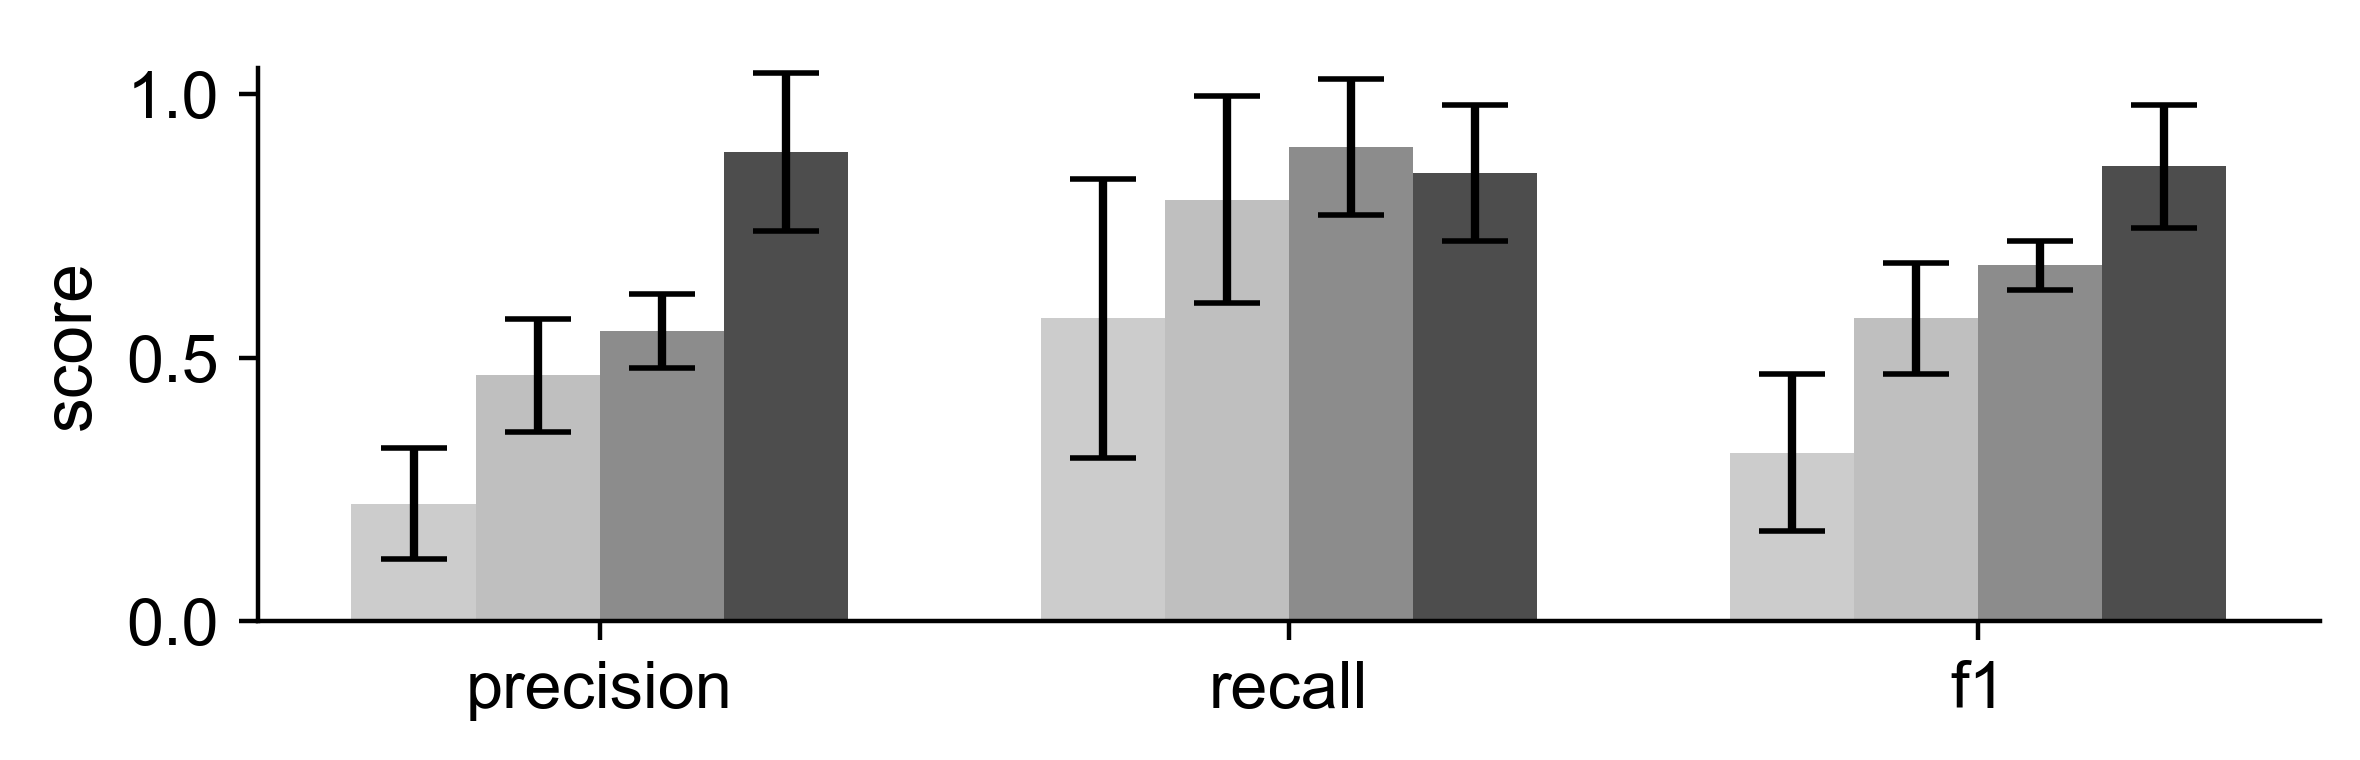

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Metric order
# -------------------------------------------------
metrics_to_plot = ["precision", "recall", "f1"]

# ---- Random ----
metrics_rand = ["precision_random", "recall_random", "f1_random"]
means_rand = best_five_df[metrics_rand].mean().values
stds_rand  = best_five_df[metrics_rand].std().values

# ---- GRNBoost2 best-F1 ----
metrics_best = ["precision_best", "recall_best", "f1_best"]
means_grn = best_five_df[metrics_best].mean().values
stds_grn  = best_five_df[metrics_best].std().values

# ---- GRNBoost2 GMM ----
metrics_gmm = ["precision_gmm", "recall_gmm", "f1_gmm"]
means_gmm = best_five_df[metrics_gmm].mean().values
stds_gmm  = best_five_df[metrics_gmm].std().values

# ---- TwINFER ----
means_twinfer = metrics_five_gene_twinfer[metrics_to_plot].mean().values
stds_twinfer  = metrics_five_gene_twinfer[metrics_to_plot].std().values
import pandas as pd
import pandas as pd

# -------------------------------
# Start from GRNBoost-derived df
# (these already share replicate index)
# -------------------------------
combined_df = best_five_df[
    [
        "precision_random", "recall_random", "f1_random",
        "precision_gmm", "recall_gmm", "f1_gmm",
        "precision_best", "recall_best", "f1_best",
    ]
].copy()

# Rename GRNBoost columns to explicit method names
combined_df = combined_df.rename(columns={
    "precision_random": "precision_random",
    "recall_random": "recall_random",
    "f1_random": "f1_random",

    "precision_gmm": "precision_gmm_gmm",
    "recall_gmm": "recall_gmm_gmm",
    "f1_gmm": "f1_gmm_gmm",

    "precision_best": "precision_gmm_best",
    "recall_best": "recall_gmm_best",
    "f1_best": "f1_gmm_best",
})

# -------------------------------
# Add TwINFER (may have different length)
# -------------------------------
df_twinfer = metrics_five_gene_twinfer[
    ["precision", "recall", "f1"]
].rename(columns={
    "precision": "precision_twinfer",
    "recall": "recall_twinfer",
    "f1": "f1_twinfer",
})

# Align by index (NaN if lengths differ)
combined_df = combined_df.join(df_twinfer, how="outer")

# -------------------------------
# Optional: column ordering
# -------------------------------
ordered_cols = [
    "precision_random", "recall_random", "f1_random",
    "precision_gmm_gmm", "recall_gmm_gmm", "f1_gmm_gmm",
    "precision_gmm_best", "recall_gmm_best", "f1_gmm_best",
    "precision_twinfer", "recall_twinfer", "f1_twinfer",
]

combined_df = combined_df[ordered_cols]


# Save
combined_df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_3_10012026/five_gene_cascade_comparison.csv", index=False)

# -------------------------------------------------
# Grouped bar plot
# -------------------------------------------------
x = np.arange(len(metrics_to_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(6, 2))

bars_rand = ax.bar(
    x - 1.5 * width,
    means_rand,
    width,
    yerr=stds_rand,
    capsize=6,
    label="random",
    color="0.8"
)

bars_gmm = ax.bar(
    x - 0.5 * width,
    means_gmm,
    width,
    yerr=stds_gmm,
    capsize=6,
    label="GRNBoost2 (Uninformed)",
    color="0.75"
)

bars_grn = ax.bar(
    x + 0.5 * width,
    means_grn,
    width,
    yerr=stds_grn,
    capsize=6,
    label="GRNBoost2 (threshold with best F1)",
    color="0.55"
)

bars_twinfer = ax.bar(
    x + 1.5 * width,
    means_twinfer,
    width,
    yerr=stds_twinfer,
    capsize=6,
    label="TwINFER",
    color="0.30"
)

# -------------------------------------------------
# Disable ALL clipping (bars, errors, axes, legend)
# -------------------------------------------------

# Bars
for container in [bars_rand, bars_gmm, bars_grn, bars_twinfer]:
    for patch in container.patches:
        patch.set_clip_on(False)

# Error bars + caps
for line in ax.lines:
    line.set_clip_on(False)

# Axes patch
ax.patch.set_clip_on(False)

# Spines
for spine in ax.spines.values():
    spine.set_clip_on(False)

# Tick labels
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_clip_on(False)

# Axis labels
ax.xaxis.label.set_clip_on(False)
ax.yaxis.label.set_clip_on(False)

# # Legend
# leg = ax.legend(
#     frameon=False,
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5)
# )
# leg.set_clip_on(False)

# Figure patch
fig.patch.set_clip_on(False)

# -------------------------------------------------
# Cosmetics
# -------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_3_10012026/"
out = Path(path_to_plots)
out.mkdir(parents=True, exist_ok=True)
matrix_type = "five_gene_cascade_comparison_v2"
fig.savefig(out / f"{matrix_type}.png", dpi=300,
            bbox_inches="tight", transparent=True)
fig.savefig(out / f"{matrix_type}.svg",
            bbox_inches="tight", transparent=True)
fig.savefig(out / f"{matrix_type}.pdf",
                bbox_inches="tight", transparent=True)

plt.show()


In [72]:
combined_df.columns

Index(['precision_random', 'recall_random', 'f1_random', 'precision_gmm_gmm',
       'recall_gmm_gmm', 'f1_gmm_gmm', 'precision_gmm_best', 'recall_gmm_best',
       'f1_gmm_best', 'precision_twinfer', 'recall_twinfer', 'f1_twinfer'],
      dtype='object')

9 9


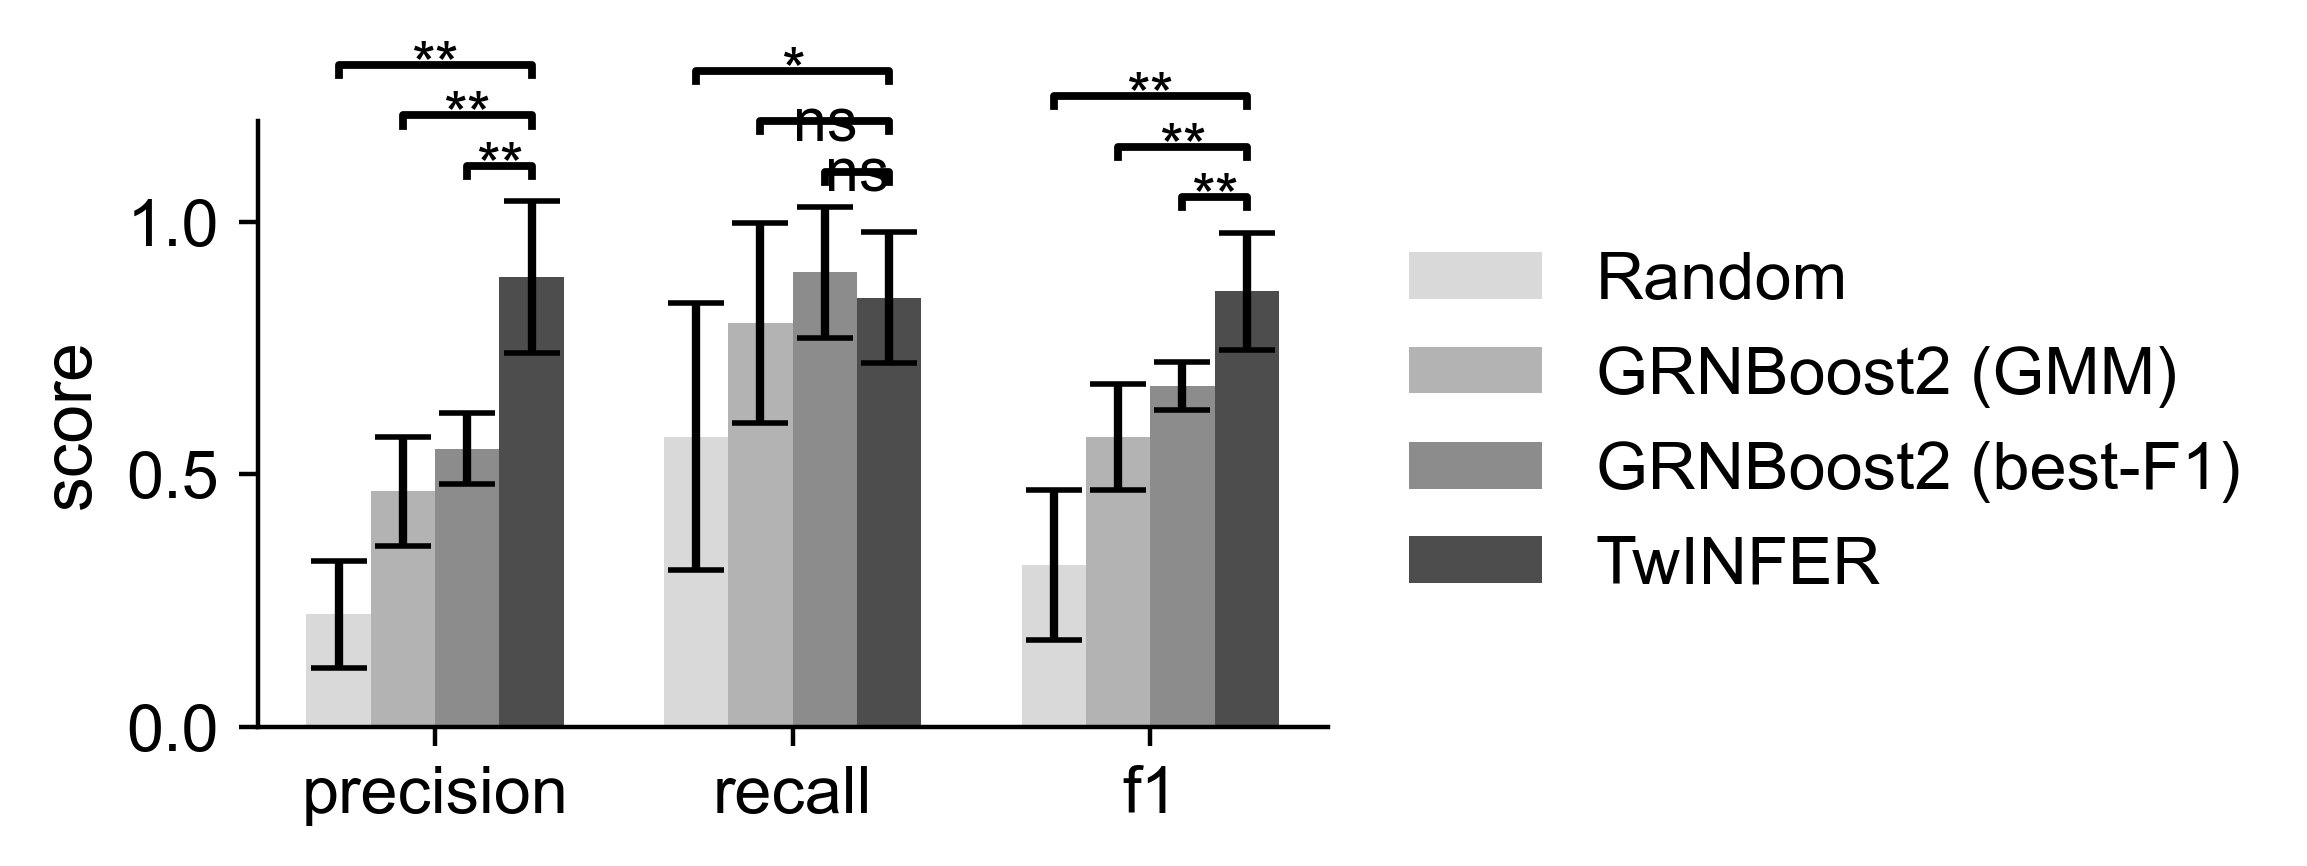

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from pathlib import Path

# -------------------------------------------------
# Metric order
# -------------------------------------------------
metrics_to_plot = ["precision", "recall", "f1"]
width = 0.18
x = np.arange(len(metrics_to_plot))

# -------------------------------------------------
# Compute means + std from existing combined_df
# -------------------------------------------------
metrics_rand = ["precision_random", "recall_random", "f1_random"]
means_rand = combined_df[metrics_rand].mean().values
stds_rand  = combined_df[metrics_rand].std().values

metrics_gmm = ["precision_gmm_gmm", "recall_gmm_gmm", "f1_gmm_gmm"]
means_gmm = combined_df[metrics_gmm].mean().values
stds_gmm  = combined_df[metrics_gmm].std().values

metrics_best = ["precision_gmm_best", "recall_gmm_best", "f1_gmm_best"]
means_best = combined_df[metrics_best].mean().values
stds_best  = combined_df[metrics_best].std().values

metrics_twin = ["precision_twinfer", "recall_twinfer", "f1_twinfer"]
means_twin = combined_df[metrics_twin].mean().values
stds_twin  = combined_df[metrics_twin].std().values


# -------------------------------------------------
# Significance symbol function (Bonferroni)
# -------------------------------------------------
def get_symbol(p):
    if p > 0.05:
        return "ns"
    elif p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    else:
        return "*"


def add_bracket(ax, x1, x2, y, h, label):

    # draw bracket
    ax.plot([x1, x1, x2, x2],
            [y, y+h, y+h, y],
            lw=1.4,
            color="black",
            clip_on=False)

    # place text ABOVE bracket with fixed offset
    ax.text(
        (x1 + x2) / 2,
        y + h + 0.05,   # constant offset
        label,
        ha="center",
        va="top",
        fontsize=11,
        clip_on=False
    )


# -------------------------------------------------
# Run paired Wilcoxon tests (collect raw p)
# -------------------------------------------------
raw_pvals = []
test_info = []

for i, metric in enumerate(metrics_to_plot):

    twin_col = f"{metric}_twinfer"
    gmm_col  = f"{metric}_gmm_gmm"
    best_col = f"{metric}_gmm_best"
    random_col = f"{metric}_random"

    subset_gmm = combined_df[[twin_col, gmm_col]].dropna()
    subset_best = combined_df[[twin_col, best_col]].dropna()
    subset_random = combined_df[[twin_col, random_col]].dropna()

    stat_random, p_random = wilcoxon(
        subset_random[twin_col],
        subset_random[random_col],
        alternative="two-sided"
    )

    stat_gmm, p_gmm = wilcoxon(
        subset_gmm[twin_col],
        subset_gmm[gmm_col],
        alternative="two-sided"
    )


    stat_best, p_best = wilcoxon(
        subset_best[twin_col],
        subset_best[best_col],
        alternative="two-sided"
    )

    raw_pvals.extend([p_random, p_gmm, p_best])

    test_info.append((i, "random", p_random))
    test_info.append((i, "gmm", p_gmm))
    test_info.append((i, "best", p_best))


# -------------------------------------------------
# Bonferroni correction (6 tests)
# -------------------------------------------------
m = 1
p_bonf = [min(p * m, 1.0) for p in raw_pvals]
print(len(p_bonf), len(test_info))
# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 2.3))

bars_rand = ax.bar(x - 1.5*width, means_rand, width,
                   yerr=stds_rand, capsize=5,
                   label="Random", color="0.85")

bars_gmm = ax.bar(x - 0.5*width, means_gmm, width,
                  yerr=stds_gmm, capsize=5,
                  label="GRNBoost2 (GMM)", color="0.70")

bars_best = ax.bar(x + 0.5*width, means_best, width,
                   yerr=stds_best, capsize=5,
                   label="GRNBoost2 (best-F1)", color="0.55")

bars_twin = ax.bar(x + 1.5*width, means_twin, width,
                   yerr=stds_twin, capsize=5,
                   label="TwINFER", color="0.30")


# Disable clipping
for container in [bars_rand, bars_gmm, bars_best, bars_twin]:
    for patch in container.patches:
        patch.set_clip_on(False)

for line in ax.lines:
    line.set_clip_on(False)

for spine in ax.spines.values():
    spine.set_clip_on(False)

ax.patch.set_clip_on(False)
fig.patch.set_clip_on(False)


# -------------------------------------------------
# Add Bonferroni-corrected brackets
# -------------------------------------------------
counter = 0
for i, metric in enumerate(metrics_to_plot):

    y_base = max(
        means_twin[i] + stds_twin[i],
        means_best[i] + stds_best[i],
        means_gmm[i] + stds_gmm[i]
    )

    # TwINFER vs Random
    p_adj = p_bonf[counter]
    label = get_symbol(p_adj)
    add_bracket(ax,
                x[i] - 1.5*width,
                x[i] + 1.5*width,
                y_base + 0.25,
                0.02,
                label)
    counter += 1

    # TwINFER vs gmm
    p_adj = p_bonf[counter]
    label = get_symbol(p_adj)
    add_bracket(ax,
                x[i] - 0.5*width,
                x[i] + 1.5*width,
                y_base + 0.15,
                0.02,
                label)
    counter += 1

    # TwINFER vs Best
    p_adj = p_bonf[counter]
    label = get_symbol(p_adj)
    add_bracket(ax,
                x[i] + 0.5*width,
                x[i] + 1.5*width,
                y_base + 0.05,
                0.02,
                label)
    counter += 1


# -------------------------------------------------
# Cosmetics
# -------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("score")
ax.set_ylim(0, 1.20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(frameon=False,
                loc="center left",
                bbox_to_anchor=(1.02, 0.5))
leg.set_clip_on(False)

plt.tight_layout()

# -------------------------------------------------
# Save
# -------------------------------------------------
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_3_10012026/"
out = Path(path_to_plots)
out.mkdir(parents=True, exist_ok=True)

fig.savefig(out / "five_gene_comparison_stats.svg",
            bbox_inches="tight", transparent=True)
fig.savefig(out / "five_gene_comparison_stats.pdf",
            bbox_inches="tight", transparent=True)
fig.savefig(out / "five_gene_comparison_stats.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.show()

In [27]:
metrics_five_gene_twinfer = pd.DataFrame(metrics_five_gene_twinfer)

## figure 1 network

In [4]:
protein_1_2 = 125265.1379158951
protein_1 = 29965.104
protein_2_ffl = 119763.6917
protein_2_cascade = 119763.6917
protein_3_cascade = 122672.08966666667
mutual_reg_2_3 = 125265.1379158951
K_matrix = [
    [0, protein_1, protein_1, 0, 0,0,0,0,0,0,0,0,0,0],
    [0, 0, 0, protein_2_ffl, 0,0,0,0,0,0,0,0,0,0],
    [0]*14,
    [0]*14,
    [0, 0, 0, 0, 0, protein_1, protein_1, 0, 0,0,0,0,0,0],
    [0,0,0,0,0,0,protein_2_ffl,protein_2_ffl,0,0,0,0,0,0],
    [0]*14,
    [0]*14,
    [0]*14,
    [0,0,0,0,0,0,0,0,0,0,protein_1,0,0,0],
    [0,0,0,0,0,0,0,0,0,0, 0, protein_2_cascade, 0, 0],
    [0,0,0,0,0,0,0,0,0,0, 0,0, protein_3_cascade,protein_3_cascade],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,mutual_reg_2_3],
    [0,0,0,0,0,0,0,0,0,0,0,0,mutual_reg_2_3,0]
]

base_config_figure_1 = {
    'n_cells': 6000,
    'simulation_time_before_division': 6000,
    'twin_simulation_time_after_division': 48,
    'rows_to_use':[[0]*14],
    'twin_measurement_resolution': 1,
    "path_to_connectivity_matrix": f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_figure_1_network.txt",  # Will be updated per network type
    "param_csv":f"{path_to_code_repo}/simulation_example_input_data/median_parameter.csv",  # Will be updated per network type
    "output_folder": "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_1_network",
    "log_file": "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_1_network/figure_1_network.jsonl",
    "type": "figure_1_network",
    "use_given_K": True,
    "K_to_use":K_matrix,
    "multiple_interaction_type": "additive",
    "number_of_parallel_parameters": 1,
    "number_of_cores_per_parameter": 56,
    "log_pi_on": False,
}

In [18]:
def process_matrix(twinfer_kwargs, id):
    # Process each network type
    all_correlation_matrices = {}
    
    # Use the first CSV file found (or you can add logic to select specific one)        
    # Update config for this network type
    config = base_config_figure_1
    network_type = "figure_1_network" 
    config["type"] = {network_type}

    def make_json_safe(obj):
        if hasattr(obj, "to_dict"):      # pandas DataFrame / Series
            return obj.to_dict()
        if isinstance(obj, set):
            return list(obj)
        return obj
        
    # Check if required files exist
    if not os.path.exists(config["path_to_connectivity_matrix"]):
        print(f"Warning: Connectivity matrix not found for {network_type}")

    if not os.path.exists(config["param_csv"]):
        print(f"Warning: Parameter CSV not found for {network_type}")
        
    try:
        # Run inference for this network type
        correlation_matrices = infer_with_twinfer(
            **twinfer_kwargs
            )
            

    except Exception as e:
        print(f"Error processing {network_type}: {str(e)}")
    
    import json
    # Store the correlation matrices
    all_correlation_matrices[network_type] = correlation_matrices
        
    # Save the directional correlation matrix for this network type
    json_safe = {
        k: make_json_safe(v)
        for k, v in correlation_matrices.items()
    }
    path_to_json_file = f"{path_to_plot_data}figure_1_network_correlation_matrices_{id}.json"
    with open(path_to_json_file, "w") as f:
        json.dump(json_safe, f, indent=2)
    print(correlation_matrices.keys())
    correlation_file_name = f"{path_to_plot_data}/filtered_directional_correlation_type_{network_type}_{id}.csv"
    gene_correlation_file_name = f"{path_to_plot_data}/gene_correlation_type_{network_type}_{id}.csv"
    correlation_matrices['unfiltered_direction_matrix'].to_csv(correlation_file_name)
    correlation_matrices['pairwise_gene_gene_correlation_matrix'].to_csv(gene_correlation_file_name)
    correlation_matrices
    print(f"Successfully processed {network_type}")
    print(f"Saved correlation matrix to: {correlation_file_name}")
    return

In [ ]:
# %%capture
path_to_simulations = f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_4/"
prefix = "df_rows_0_0_0_0_0_0_0_0_0_0_0_0_0_0"

list_simulations = [
    f.path
    for f in os.scandir(path_to_simulations)
    if f.is_file() and f.name.startswith(prefix)
]
for id, file_name in enumerate(list_simulations):
    twinfer_kwargs_figure_1 = {
        "path_to_simulation_file": file_name,
        "base_config": base_config_figure_1,
        "t1": 1,  #time [hours] after division when t1 sample is collected
        "t2": 20, #time [hours] after division when t2 sample is collected
        "check_for_steady_state": True,
        "threshold_gene_gene_corr": 0.04, #Use direct threshold (used ONLY if use_scramble is False)
        "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
        "p_val_threshold_scrambled_gene_correlation": 0.002, #used ONLY if use_scramble is True
        "show_scrambled_distribution_gene_correlation": False, 
        "z_score_threshold_two_states": 12, #Z-score False to detect multi-states in the system
        "p_value_threshold_cross_correlation": 0.01,
        "plot_correlation_matrices_as_heatmap": True,
        "have_any_output": False,
        "seed": 101010,
        "infer_direction_for_which_edges":"all-potential-regulation", #can be either single-state, all-potential-regulation (gene correlation is significant) or all-edges,
        "merge_time_points": True, #If True, then cells from the two timepoints will be used to calculate gene correlations and random-pair difference correlations
        "n_cores": 18
    }
    process_matrix(twinfer_kwargs_figure_1, id)
    

In [ ]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
matrix_file = Path(f"{path_to_code_repo}/simulation_example_input_data/connectivity_matrix_figure_1_network.txt")
json_dir    = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/")          # contains edges_1.json, edges_2.json, ...
# plot_dir    = Path("path/to/output/plots")
# plot_dir.mkdir(parents=True, exist_ok=True)

json_files = sorted(json_dir.glob("figure_1_network_correlation_matrices_*.json"))
# ============================================================
# SPECIAL RULES
# ============================================================
FORCE_TWO_STATE   = {frozenset(["gene_2", "gene_3"])}
FORCE_ONE_DIR     = {("gene_6", "gene_7")}
FORBID_TWO_STATE  = {frozenset(["gene_13", "gene_14"])}

# ============================================================
# LOAD BINARY MATRIX (ONCE)
# ============================================================
gt = pd.read_csv(matrix_file, header=None)
n = gt.shape[0]
genes = [f"gene_{i+1}" for i in range(n)]
gt.index = genes
gt.columns = genes

gene_labels = [f"g{i+1}" for i in range(n)]

from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Rectangle
import seaborn as sns
from pathlib import Path

def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = (0 - vmin) / (vmax - vmin)
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)
    
# ============================================================
# HELPERS
# ============================================================
def pred_state(pred, g1, g2):
    a = pred.loc[g1, g2]
    b = pred.loc[g2, g1]
    if a == 1 and b == 1:
        return "two"
    elif a == 1:
        return "g1_to_g2"
    elif b == 1:
        return "g2_to_g1"
    else:
        return "none"

metrics = []

# ============================================================
# MAIN LOOP
# ============================================================
for jf in json_files:

    # ---------------- load JSON ----------------
    with open(jf, "r") as f:
        cm = json.load(f)

    final_directed_edges = cm["final_directed_edges"]
    unfiltered_direction_matrix = pd.DataFrame(cm["unfiltered_direction_matrix"])
    multiple_states_and_reg = cm["gene_lists"]["multiple_states_and_reg"]
    all_gene_pairs = cm['all_gene_pairs']

    # enforce gene order
    unfiltered_direction_matrix.index = genes
    unfiltered_direction_matrix.columns = genes

    # ---------------- score ----------------
    # ============================================================
    # DIRECTED EDGE SCORING WITH ONE EXCEPTION (g2,g3)
    # ============================================================
    FP_edge = []
    FN_edge = []
    TP = FP = FN = TN = 0

    # quick lookup for predicted edges
    predicted_edges = set(tuple(e) for e in final_directed_edges)

    # special unordered exception pair
    EXCEPTION_PAIR = frozenset(["gene_2", "gene_3"])
    can_be_2_states =  [["gene_2", "gene_3"], ["gene_6", "gene_6"],["gene_7", "gene_8"]]

    for i, gi in enumerate(genes):
        for j, gj in enumerate(genes):
            if gi == gj:
                continue

            pair = frozenset([gi, gj])

            # ----------------------------------------------------
            # EXCEPTION: (gene_2, gene_3)
            # ----------------------------------------------------
            if pair == EXCEPTION_PAIR:
                # evaluate ONCE per unordered pair
                if gi > gj:
                    continue  # avoid double counting

                has_gi_gj = (gi, gj) in predicted_edges
                has_gj_gi = (gj, gi) in predicted_edges

                if (has_gi_gj and has_gj_gi) or (not has_gi_gj and not has_gj_gi):
                    if [gi, gj] in multiple_states_and_reg or [gj, gi] in multiple_states_and_reg:
                        print(gi, gj, multiple_states_and_reg)
                        continue
                    else:
                        FP += 2
                        FP_edge.append((gi,gj))
                        FP_edge.append((gj, gi))
                else:
                    FP += 1
                    FP_edge.append((gi,gj))
                continue

            # ----------------------------------------------------
            # NORMAL DIRECTED SCORING
            # ----------------------------------------------------
            gt_edge = gt.loc[gi, gj] == 1
            pred_edge = (gi, gj) in predicted_edges

            if gt_edge and pred_edge:
                if [gi, gj] in multiple_states_and_reg and [gi, gj] not in can_be_2_states:
                    FN += 1
                else:
                    TP += 1
            elif gt_edge and not pred_edge:
                FN += 1
                FN_edge.append((gi,gj))
            elif not gt_edge and pred_edge:
                FP += 1
                FP_edge.append((gi,gj))
            else:
                TN += 1

    # ============================================================
    # METRICS
    # ============================================================
    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall    = TP / (TP + FN) if (TP + FN) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"F1={f1:.4f}")
    print(f"FP: {FP_edge}")
    print(f"FN: {FN_edge}")

    metrics.append({
        "json": jf.name,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })


    #Plot TwINFER output
    gene_list = sorted(
        {g for pair in all_gene_pairs for g in pair},
        key=lambda x: int(x.split("_")[1])
    )
    gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
    # direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
    data_matrix = unfiltered_direction_matrix.to_numpy(float)
    masked_matrix = np.fill_diagonal(data_matrix, np.nan)
    fig = plt.figure(figsize=(6,6))
    gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
    cbar_ax = fig.add_subplot(gs[0])
    heatmap_ax = fig.add_subplot(gs[1])
    plot_matrix = data_matrix.copy()
    plot_matrix[:] = 0.0

    # Restore only final-ege correlations
    for g1, g2 in final_directed_edges:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            plot_matrix[i, j] = data_matrix[i, j]
            plot_matrix[j, i] = data_matrix[j, i]
    np.fill_diagonal(plot_matrix, np.nan)
    vmin = np.nanmin(plot_matrix)
    vmax = np.nanmax(plot_matrix)
    cmap = make_reds_blues_colormap(vmin = vmin, vmax = vmax)

    cmap.set_bad(color="#D9D9D9")
    # --- draw heatmap ---
    sns.heatmap(
        plot_matrix,
        ax=heatmap_ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        square=True,
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={'orientation': 'horizontal'},
        linewidths=0.5,
        linecolor="black",
        # center=center
    )
    for g1, g2 in multiple_states_and_reg:
        if g1 in gene_list and g2 in gene_list:
            i = gene_list.index(g1)
            j = gene_list.index(g2)
            print(i, j)

            # Draw diagonal in cell (i, j) - top-left to bottom-right
            heatmap_ax.plot(
                [j, j+1],      # x: left → right
                [i, i+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )
            
            # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
            heatmap_ax.plot(
                [i, i+1],      # x: left → right
                [j, j+1],      # y: top → bottom
                linestyle="--",
                color="black",
                linewidth=1.5,
                clip_on=False
            )

    # --- labels ---
    cbar_ax.xaxis.set_label_position('top')
    cbar_ax.xaxis.tick_top()

    n = len(gene_labels)
    tick_pos = np.arange(n) + 0.5

    heatmap_ax.set_xticks(tick_pos)
    heatmap_ax.set_yticks(tick_pos)
    heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
    heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")

    # keep limits tight to cells
    heatmap_ax.set_xlim(0, n)
    heatmap_ax.set_ylim(n, 0)

    # --- transparent background ---
    # plt.tight_layout()
    fig.patch.set_alpha(0)
    for ax in [heatmap_ax, cbar_ax]:
        ax.set_facecolor("none")
    for im in heatmap_ax.get_images() + cbar_ax.get_images():
        im.set_facecolor((1, 1, 1, 0))
        im.set_edgecolor((1, 1, 1, 0))
    for spine in heatmap_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
        spine.set_clip_on(False)

    plt.close()

# ============================================================
# METRICS SUMMARY
# ============================================================
metrics_df = pd.DataFrame(metrics)
# print(metrics_df)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq


def plot_gmm_diagnostics(
    ax,
    y_score,
    gmm,
    post,
    threshold_type,
    t,
    posterior_cutoff=None,
):

    """
    Diagnostic plot for GMM thresholding.

    Parameters
    ----------
    y_score : 1D np.ndarray
        Dense importance scores (flattened, diagonal removed).
    gmm : sklearn.mixture.GaussianMixture or None
        Fitted GMM (None if no GMM used).
    post : 1D np.ndarray or None
        Posterior probabilities for high-importance component
        (None when using intersection threshold).
    threshold_type : str
        One of {"GMM", "GMM_intersection", "GMM_empty", "no_gmm"}.
    posterior_cutoff : float or None
        Posterior cutoff (only used when threshold_type == "GMM").
    """

    # ------------------------------------------------------------
    # Use only nonzero scores for visualization
    # ------------------------------------------------------------
    x = y_score[y_score > 0]

    # ------------------------------------------------------------
    # No signal case
    # ------------------------------------------------------------
    # if x.size == 0:
    #     txt = ax.text(
    #         0.5, 0.5,
    #         "No nonzero edges",
    #         ha="center", va="center",
    #         transform=ax.transAxes,
    #         fontsize=11
    #     )
    #     txt.set_clip_on(False)

    #     ax.set_axis_off()
    #     fig.patch.set_clip_on(False)
    #     plt.tight_layout()
    #     plt.show()
    #     return

    # ------------------------------------------------------------
    # Histogram
    # ------------------------------------------------------------
    n, bins, patches = ax.hist(
        x,
        bins=40,
        density=True,
        color="#bfbfbf",
        edgecolor="black",
        linewidth=0.5,
        label="importance histogram"
    )

    for p in patches:
        p.set_clip_on(False)

    # ------------------------------------------------------------
    # GMM curves (for GMM and GMM_intersection)
    # ------------------------------------------------------------
    if gmm is not None and threshold_type in ("GMM", "GMM_intersection"):

        x_grid = np.linspace(x.min(), x.max(), 1000)

        weights = gmm.weights_
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_.flatten())

        # individual components
        for w, mu, sigma in zip(weights, means, stds):
            line, = ax.plot(
                x_grid,
                w * norm.pdf(x_grid, mu, sigma),
                lw=2,
                alpha=0.8
            )
            line.set_clip_on(False)

        # mixture
        mixture_pdf = sum(
            w * norm.pdf(x_grid, mu, sigma)
            for w, mu, sigma in zip(weights, means, stds)
        )
        mix_line, = ax.plot(
            x_grid,
            mixture_pdf,
            color="#4d4d4d",
            lw=1.5,
            ls="--",
            label="GMM mixture"
        )
        mix_line.set_clip_on(False)

    # ------------------------------------------------------------
    # Posterior cutoff line
    # ------------------------------------------------------------
    if (
        threshold_type == "GMM"
        and post is not None
        and posterior_cutoff is not None
        and np.any(post >= posterior_cutoff)
    ):
        thr = np.min(x[post >= posterior_cutoff])
        vline = ax.axvline(
            thr,
            color="red",
            lw=2,
            ls=":",
            label=f"posterior ≥ {posterior_cutoff}"
        )
        vline.set_clip_on(False)

    # ------------------------------------------------------------
    # Intersection cutoff line
    # ------------------------------------------------------------
    if gmm is not None and threshold_type == "GMM_intersection":

        weights = gmm.weights_
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_.flatten())

        order = np.argsort(means)
        w1, w2 = weights[order]
        m1, m2 = means[order]
        s1, s2 = stds[order]

        f = lambda z: (
            w1 * norm.pdf(z, m1, s1)
            - w2 * norm.pdf(z, m2, s2)
        )

        try:
            thr = brentq(f, m1, m2)
            vline = ax.axvline(
                thr,
                color="red",
                lw=2.2,
                ls=":",
                label="importance threshold (GMM-based)"
            )
            vline.set_clip_on(False)
        except ValueError:
            pass
        vline_2 = ax.axvline(
                t,
                color="black",
                lw=2.2,
                ls="-.",
                label="importance threshold (best F1-score)"
        )
        vline_2.set_clip_on(False)
    # ------------------------------------------------------------
    # Cosmetics
    # ------------------------------------------------------------
    ax.set_xlabel("importance")
    ax.set_ylabel("density")
    # ax.set_title(f"GMM diagnostics ({threshold_type})")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Disable clipping everywhere
    ax.patch.set_clip_on(False)
    for spine in ax.spines.values():
        spine.set_clip_on(False)

    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_clip_on(False)

    ax.xaxis.label.set_clip_on(False)
    ax.yaxis.label.set_clip_on(False)

    handles, labels = ax.get_legend_handles_labels()
    return handles, labels



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

In [61]:
# ============================================================
# 1. Load ground-truth connectivity matrix
# ============================================================

gt_path = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/simulation_example_input_data/connectivity_matrix_figure_1_network.txt"

# Load as numpy array
gt_matrix = np.loadtxt(gt_path, delimiter= ",")

n_genes = gt_matrix.shape[0]
genes = [f"gene_{i+1}_mRNA" for i in range(n_genes)]

gt_df = pd.DataFrame(
    gt_matrix,
    index=genes,
    columns=genes,
)

# Binary ground truth: edge exists or not
gt_binary = (gt_df.values != 0).astype(int)
np.fill_diagonal(gt_binary, 0)

# ============================================================
# 2. Build predicted score matrix from network
# ============================================================
import os, pathlib
from pathlib import Path
network_files = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/f1_scores/") 
best_rows = []
list_network_files = sorted(network_files.glob("grn_boost_figure_1_network_inference_*.csv"))
for i, network_path in enumerate(list_network_files):

    # ---------------- load network ----------------
    network = pd.read_csv(network_path)

    # ---------------- dense prediction matrix ----------------
    pred_df = (
        network
        .pivot(index="TF", columns="target", values="importance")
        .reindex(index=genes, columns=genes, fill_value=0.0)
    )
    np.fill_diagonal(pred_df.values, 0.0)

    # ---------------- vectorize for metrics ----------------
    y_true = gt_binary.flatten()
    y_score = pred_df.values.flatten()

    mask = ~np.eye(len(genes), dtype=bool).flatten()
    y_true = y_true[mask]
    y_score = y_score[mask]

    # ========================================================
    # Best-F1 threshold (dense, comparable to GT)
    # ========================================================
    rows = []
    for t in np.unique(y_score)[::-1]:
        y_pred = (y_score >= t).astype(int)
        if y_pred.sum() == 0:
            continue

        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "n_edges": y_pred.sum(),
        })

    best = pd.DataFrame(rows).loc[lambda df: df["f1"].idxmax()]

    # ========================================================
    # GMM threshold (fit on predicted edges ONLY)
    # ========================================================
    x = network["importance"].values.reshape(-1, 1)
    MIN_POINTS = 10
    if len(x) >= MIN_POINTS and len(np.unique(x)) >= 2:
        gmm = GaussianMixture(
            n_components=2,
            covariance_type="full",
            random_state=0
        )
        gmm.fit(x)

        from scipy.stats import norm
        from scipy.optimize import brentq

        weights = gmm.weights_
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_.flatten())

        # sort components by mean
        order = np.argsort(means)
        w1, w2 = weights[order]
        m1, m2 = means[order]
        s1, s2 = stds[order]
        print(np.sum(gmm.weights_))

        # intersection of weighted PDFs
        f = lambda x: w1 * norm.pdf(x, m1, s1) - w2 * norm.pdf(x, m2, s2)

        try:
            importance_threshold = brentq(f, m1, m2)
            threshold_type = "GMM_intersection"
        except ValueError:
            importance_threshold = np.inf   # no clean intersection
            threshold_type = "GMM_no_intersection"


    # ---------------- apply GMM threshold to dense matrix ----------------
    y_pred_gmm = (y_score >= importance_threshold).astype(int)

    if y_pred_gmm.sum() > 0:
        p_gmm = precision_score(y_true, y_pred_gmm, zero_division=0)
        r_gmm = recall_score(y_true, y_pred_gmm)
        f1_gmm = f1_score(y_true, y_pred_gmm)
    else:
        p_gmm = r_gmm = f1_gmm = 0.0
    post = None
    posterior_cutoff = None
    threshold_type = "GMM_intersection"

    # h1, l1 = plot_gmm_diagnostics(
    #     axes[1],
    #     y_score,
    #     gmm,
    #     post,
    #     threshold_type,
    #     best['threshold'] -0.1,
    #     posterior_cutoff
    # )

    N_RANDOM = 1
    rng = np.random.default_rng(i)

    precisions = []
    recalls = []
    f1s = []

    for _ in range(N_RANDOM):
        y_pred_rand = rng.binomial(1, 0.5, size=len(y_true))

        precisions.append(
            precision_score(y_true, y_pred_rand, zero_division=0)
        )
        recalls.append(
            recall_score(y_true, y_pred_rand)
        )
        f1s.append(
            f1_score(y_true, y_pred_rand)
        )

    rand_precision = np.mean(precisions)
    rand_recall    = np.mean(recalls)
    rand_f1        = np.mean(f1s)

    rand_precision_sd = np.std(precisions)
    rand_recall_sd    = np.std(recalls)
    rand_f1_sd        = np.std(f1s)


    
    # ========================================================
    # Store
    # ========================================================
    best_rows.append({
        "network": network_path.name,

        "f1_best": best["f1"],
        "precision_best": best["precision"],
        "recall_best": best["recall"],
        "n_edges_best": best["n_edges"],

        "f1_gmm": f1_gmm,
        "precision_gmm": p_gmm,
        "recall_gmm": r_gmm,
        "n_edges_gmm": int(y_pred_gmm.sum()),
        "gmm_threshold": float(importance_threshold),
        "gmm_mode": threshold_type,
        "f1_random": rand_f1,
        "precision_random": rand_precision,
        "recall_random": rand_recall
    })

best_f1_df_figure_1 = pd.DataFrame(best_rows)
best_f1_df_figure_1


0.9999999999999999
1.0
1.0
1.0
1.0
0.9999999999999999
1.0
1.0
1.0
1.0
1.0


,network,f1_best,precision_best,recall_best,n_edges_best,f1_gmm,precision_gmm,recall_gmm,n_edges_gmm,gmm_threshold,gmm_mode,f1_random,precision_random,recall_random
0,grn_boost_figure_1_network_inference_0.csv,0.461538,0.346154,0.692308,26.0,0.439024,0.321429,0.692308,28,2.854634,GMM_intersection,0.141593,0.080000,0.615385
1,grn_boost_figure_1_network_inference_1.csv,0.518519,0.500000,0.538462,14.0,0.440000,0.297297,0.846154,37,2.673939,GMM_intersection,0.094340,0.053763,0.384615
2,grn_boost_figure_1_network_inference_2.csv,0.592593,0.571429,0.615385,14.0,0.444444,0.312500,0.769231,32,3.034188,GMM_intersection,0.166667,0.094737,0.692308
3,grn_boost_figure_1_network_inference_3.csv,0.480000,0.500000,0.461538,12.0,0.340426,0.235294,0.615385,34,2.671633,GMM_intersection,0.115385,0.065934,0.461538
4,grn_boost_figure_1_network_inference_4.csv,0.486486,0.375000,0.692308,24.0,0.416667,0.285714,0.769231,35,2.519259,GMM_intersection,0.086957,0.049020,0.384615
5,grn_boost_figure_1_network_inference_5.csv,0.480000,0.500000,0.461538,12.0,0.408163,0.277778,0.769231,36,2.532982,GMM_intersection,0.135922,0.077778,0.538462
6,grn_boost_figure_1_network_inference_6.csv,0.571429,0.413793,0.923077,29.0,0.558140,0.400000,0.923077,30,2.917155,GMM_intersection,0.142857,0.080808,0.615385
7,grn_boost_figure_1_network_inference_7.csv,0.488889,0.343750,0.846154,32.0,0.400000,0.261905,0.846154,42,2.500195,GMM_intersection,0.162162,0.091837,0.692308
8,grn_boost_figure_1_network_inference_8.csv,0.592593,0.571429,0.615385,14.0,0.400000,0.281250,0.692308,32,2.924130,GMM_intersection,0.127660,0.074074,0.461538
9,grn_boost_figure_1_network_inference_9.csv,0.516129,0.444444,0.615385,18.0,0.444444,0.312500,0.769231,32,2.812034,GMM_intersection,0.125000,0.070707,0.538462


In [64]:
metrics = pd.DataFrame(metrics)

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Metric order
# -------------------------------------------------
metrics_to_plot = ["precision", "recall", "f1"]

# ---- Random ----
metrics_rand = ["precision_random", "recall_random", "f1_random"]
means_rand = best_f1_df_figure_1[metrics_rand].mean().values
stds_rand  = best_f1_df_figure_1[metrics_rand].std().values

# ---- GRNBoost2 best-F1 ----
metrics_best = ["precision_best", "recall_best", "f1_best"]
means_grn = best_f1_df_figure_1[metrics_best].mean().values
stds_grn  = best_f1_df_figure_1[metrics_best].std().values

# ---- GRNBoost2 GMM ----
metrics_gmm = ["precision_gmm", "recall_gmm", "f1_gmm"]
means_gmm = best_f1_df_figure_1[metrics_gmm].mean().values
stds_gmm  = best_f1_df_figure_1[metrics_gmm].std().values

# ---- TwINFER ----
means_twinfer = metrics[metrics_to_plot].mean().values
stds_twinfer  = metrics[metrics_to_plot].std().values
import pandas as pd
import pandas as pd

# -------------------------------
# Start from GRNBoost-derived df
# (these already share replicate index)
# -------------------------------
combined_df = best_five_df[
    [
        "precision_random", "recall_random", "f1_random",
        "precision_gmm", "recall_gmm", "f1_gmm",
        "precision_best", "recall_best", "f1_best",
    ]
].copy()

# Rename GRNBoost columns to explicit method names
combined_df = combined_df.rename(columns={
    "precision_random": "precision_random",
    "recall_random": "recall_random",
    "f1_random": "f1_random",

    "precision_gmm": "precision_gmm_gmm",
    "recall_gmm": "recall_gmm_gmm",
    "f1_gmm": "f1_gmm_gmm",

    "precision_best": "precision_gmm_best",
    "recall_best": "recall_gmm_best",
    "f1_best": "f1_gmm_best",
})

# -------------------------------
# Add TwINFER (may have different length)
# -------------------------------
df_twinfer = metrics_five_gene_twinfer[
    ["precision", "recall", "f1"]
].rename(columns={
    "precision": "precision_twinfer",
    "recall": "recall_twinfer",
    "f1": "f1_twinfer",
})

# Align by index (NaN if lengths differ)
combined_df = combined_df.join(df_twinfer, how="outer")

# -------------------------------
# Optional: column ordering
# -------------------------------
ordered_cols = [
    "precision_random", "recall_random", "f1_random",
    "precision_gmm_gmm", "recall_gmm_gmm", "f1_gmm_gmm",
    "precision_gmm_best", "recall_gmm_best", "f1_gmm_best",
    "precision_twinfer", "recall_twinfer", "f1_twinfer",
]

combined_df = combined_df[ordered_cols]



9 9


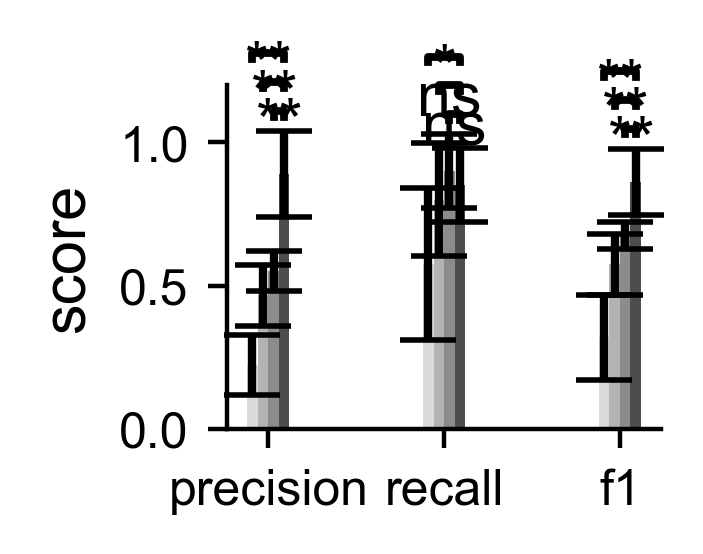

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from pathlib import Path

# -------------------------------------------------
# Metric order
# -------------------------------------------------
metrics_to_plot = ["precision", "recall", "f1"]
width = 0.18/3
x = np.arange(len(metrics_to_plot))

# -------------------------------------------------
# Compute means + std from existing combined_df
# -------------------------------------------------
metrics_rand = ["precision_random", "recall_random", "f1_random"]
means_rand = combined_df[metrics_rand].mean().values
stds_rand  = combined_df[metrics_rand].std().values

metrics_gmm = ["precision_gmm_gmm", "recall_gmm_gmm", "f1_gmm_gmm"]
means_gmm = combined_df[metrics_gmm].mean().values
stds_gmm  = combined_df[metrics_gmm].std().values

metrics_best = ["precision_gmm_best", "recall_gmm_best", "f1_gmm_best"]
means_best = combined_df[metrics_best].mean().values
stds_best  = combined_df[metrics_best].std().values

metrics_twin = ["precision_twinfer", "recall_twinfer", "f1_twinfer"]
means_twin = combined_df[metrics_twin].mean().values
stds_twin  = combined_df[metrics_twin].std().values


# -------------------------------------------------
# Significance symbol function (Bonferroni)
# -------------------------------------------------
def get_symbol(p):
    if p > 0.05:
        return "ns"
    elif p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    else:
        return "*"


def add_bracket(ax, x1, x2, y, h, label):

    # draw bracket
    ax.plot([x1, x1, x2, x2],
            [y, y+h, y+h, y],
            lw=1.4,
            color="black",
            clip_on=False)

    # place text ABOVE bracket with fixed offset
    ax.text(
        (x1 + x2) / 2,
        y + h + 0.05,   # constant offset
        label,
        ha="center",
        va="top",
        fontsize=11,
        clip_on=False
    )


# -------------------------------------------------
# Run paired Wilcoxon tests (collect raw p)
# -------------------------------------------------
raw_pvals = []
test_info = []

for i, metric in enumerate(metrics_to_plot):

    twin_col = f"{metric}_twinfer"
    gmm_col  = f"{metric}_gmm_gmm"
    best_col = f"{metric}_gmm_best"
    random_col = f"{metric}_random"

    subset_gmm = combined_df[[twin_col, gmm_col]].dropna()
    subset_best = combined_df[[twin_col, best_col]].dropna()
    subset_random = combined_df[[twin_col, random_col]].dropna()

    stat_random, p_random = wilcoxon(
        subset_random[twin_col],
        subset_random[random_col],
        alternative="two-sided"
    )

    stat_gmm, p_gmm = wilcoxon(
        subset_gmm[twin_col],
        subset_gmm[gmm_col],
        alternative="two-sided"
    )


    stat_best, p_best = wilcoxon(
        subset_best[twin_col],
        subset_best[best_col],
        alternative="two-sided"
    )

    raw_pvals.extend([p_random, p_gmm, p_best])

    test_info.append((i, "random", p_random))
    test_info.append((i, "gmm", p_gmm))
    test_info.append((i, "best", p_best))


# -------------------------------------------------
# Bonferroni correction (6 tests)
# -------------------------------------------------
m = 1
p_bonf = [min(p * m, 1.0) for p in raw_pvals]
print(len(p_bonf), len(test_info))
# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(133.33/72, 110.14/72))

bars_rand = ax.bar(x - 1.5*width, means_rand, width,
                   yerr=stds_rand, capsize=5,
                   label="Random", color="0.85")

bars_gmm = ax.bar(x - 0.5*width, means_gmm, width,
                  yerr=stds_gmm, capsize=5,
                  label="GRNBoost2 (GMM)", color="0.70")

bars_best = ax.bar(x + 0.5*width, means_best, width,
                   yerr=stds_best, capsize=5,
                   label="GRNBoost2 (best-F1)", color="0.55")

bars_twin = ax.bar(x + 1.5*width, means_twin, width,
                   yerr=stds_twin, capsize=5,
                   label="TwINFER", color="0.30")


# Disable clipping
for container in [bars_rand, bars_gmm, bars_best, bars_twin]:
    for patch in container.patches:
        patch.set_clip_on(False)

for line in ax.lines:
    line.set_clip_on(False)

for spine in ax.spines.values():
    spine.set_clip_on(False)

ax.patch.set_clip_on(False)
fig.patch.set_clip_on(False)


# -------------------------------------------------
# Add Bonferroni-corrected brackets
# -------------------------------------------------
counter = 0
for i, metric in enumerate(metrics_to_plot):

    y_base = max(
        means_twin[i] + stds_twin[i],
        means_best[i] + stds_best[i],
        means_gmm[i] + stds_gmm[i]
    )

    # TwINFER vs Random
    p_adj = p_bonf[counter]
    label = get_symbol(p_adj)
    add_bracket(ax,
                x[i] - 1.5*width,
                x[i] + 1.5*width,
                y_base + 0.25,
                0.02,
                label)
    counter += 1

    # TwINFER vs gmm
    p_adj = p_bonf[counter]
    label = get_symbol(p_adj)
    add_bracket(ax,
                x[i] - 0.5*width,
                x[i] + 1.5*width,
                y_base + 0.15,
                0.02,
                label)
    counter += 1

    # TwINFER vs Best
    p_adj = p_bonf[counter]
    label = get_symbol(p_adj)
    add_bracket(ax,
                x[i] + 0.5*width,
                x[i] + 1.5*width,
                y_base + 0.05,
                0.02,
                label)
    counter += 1

# -------------------------------------------------
# Cosmetics
# -------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("score")
ax.set_ylim(0, 1.20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# leg = ax.legend(frameon=False,
#                 loc="center left",
#                 bbox_to_anchor=(1.02, 0.5))
leg.set_clip_on(False)

plt.tight_layout()

# -------------------------------------------------
# Save
# -------------------------------------------------
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_4_f1/"
out = Path(path_to_plots)
out.mkdir(parents=True, exist_ok=True)

fig.savefig(out / "figure_1_stats.svg",
            bbox_inches="tight", transparent=True)
fig.savefig(out / "figure_1_stats.pdf",
            bbox_inches="tight", transparent=True)
fig.savefig(out / "figure_1_stats.png",
            dpi=300, bbox_inches="tight", transparent=True)

plt.show()


/tmp/ipykernel_55092/2823687750.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels = ['0', '0.5', '1.0'],fontsize=9)


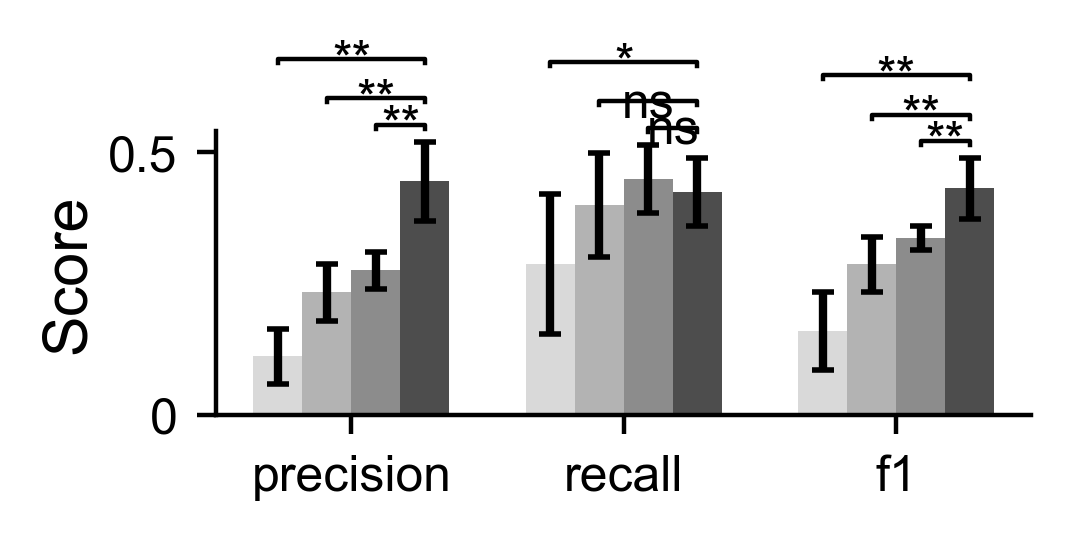

In [115]:
# -------------------------------------------------
# Figure size in points → inches
# -------------------------------------------------
plt.close("all")
def add_bracket(ax, x1, x2, y, h, label):
    ax.plot([x1, x1, x2, x2],
            [y, y+h, y+h, y],
            lw=0.8,
            color="black",
            clip_on=False)

    ax.text((x1 + x2) / 2,
            y + h -0.1,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
            clip_on=False)
    
pt_to_inch = 1 / 72
fig = plt.figure(figsize=(200 * pt_to_inch, 110 * pt_to_inch))
ax = fig.add_subplot(111)


# -------------------------------------------------
# Bar width (compact but readable)
# -------------------------------------------------
width = 0.18


# -------------------------------------------------
# Bars
# -------------------------------------------------
bars_rand = ax.bar(x - 1.5*width, means_rand, width,
                   yerr=stds_rand, capsize=2,
                   color="0.85")

bars_gmm = ax.bar(x - 0.5*width, means_gmm, width,
                  yerr=stds_gmm, capsize=2,
                  color="0.70")

bars_best = ax.bar(x + 0.5*width, means_best, width,
                   yerr=stds_best, capsize=2,
                   color="0.55")

bars_twin = ax.bar(x + 1.5*width, means_twin, width,
                   yerr=stds_twin, capsize=2,
                   color="0.30")


# -------------------------------------------------
# Proper Bonferroni correction
# -------------------------------------------------
m = 1
p_bonf = [min(p * m, 1.0) for p in raw_pvals]


# -------------------------------------------------
# Add brackets (tight vertical spacing)
# -------------------------------------------------
counter = 0
for i in range(len(metrics_to_plot)):

    y_base = max(
        means_twin[i] + stds_twin[i],
        means_best[i] + stds_best[i],
        means_gmm[i] + stds_gmm[i]
    )

    # TwINFER vs Random
    add_bracket(ax,
                x[i] - 1.5*width,
                x[i] + 1.5*width,
                y_base + 0.3,
                0.015,
                get_symbol(p_bonf[counter]))
    counter += 1

    # TwINFER vs GMM
    add_bracket(ax,
                x[i] - 0.5*width,
                x[i] + 1.5*width,
                y_base + 0.15,
                0.015,
                get_symbol(p_bonf[counter]))
    counter += 1

    # TwINFER vs Best
    add_bracket(ax,
                x[i] + 0.5*width,
                x[i] + 1.5*width,
                y_base + 0.05,
                0.015,
                get_symbol(p_bonf[counter]))
    counter += 1


# -------------------------------------------------
# Cosmetics
# -------------------------------------------------
ax.set_ylabel("Score", fontsize=11, labelpad=2)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=9)
ax.tick_params(axis='y', labelsize=9)

ax.set_ylim(0, 1.08)
ax.set_yticklabels(labels = ['0', '0.5', '1.0'],fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(out / "figure_1_stats.svg",
            bbox_inches="tight", transparent=True)
fig.savefig(out / "figure_1_stats.pdf",
            bbox_inches="tight", transparent=True)
fig.savefig(out / "figure_1_stats.png",
            dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [ ]:
handles = h1 + h2
labels = l1 + l2

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False
)

plt.subplots_adjust(bottom=0.25)
# Save z-score plot
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_4/"
fig.savefig(f"{path_to_plots}/gmm_plot.pdf", 
           format="pdf", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
fig.savefig(f"{path_to_plots}/gmm_plot.svg", 
           format="svg", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
fig.savefig(f"{path_to_plots}/gmm_plot.png", 
           format="png", 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)

fig.show()

In [ ]:
import importlib.metadata
print(importlib.metadata.version("arboreto"))
